# V_CRG_STUDENT_COURSE — Preprocessing V5 Final Reviewed

Scope:
- Work only on `V_CRG_STUDENT_COURSE`.
- This notebook performs preprocessing and data-quality preparation only.
- No models.
- No course difficulty.
- No recommendation logic.

Main corrections included:
- No dependency on `is_last_try`.
- Attempt ordering uses `part_id_base` first, then `student_course_id_base`, then `_source_row_number_v5`.
- Register-status duplicate handling keeps `E` and `R` in duplicate student-course-part groups and archives non-E/R rows only in those duplicate groups.
- Fractional `course_credits` rows are reported for audit and can remain in the final clean attempts table.
- `course_credits == 0` and `course_credits == 24` are archived/dropped according to the current decision.
- Critical issues are clearly flagged.
- Final clean table keeps only focused, useful columns.


In [1]:
from pathlib import Path
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

VERSION = "v5"

PROJECT_ROOT = Path(r"D:/AI/Real projects/Academic_Advisor")

RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "v_crg_student_course_raw.parquet"
)

PREPROCESSED_DIR = (
    PROJECT_ROOT# 
    / "data"
    / "preprocessed"
    / "V_CRG_STUDENT_COURSE"
)

FEATURES_DIR = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "V_CRG_STUDENT_COURSE"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "V_CRG_STUDENT_COURSE"
)

PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("VERSION:", VERSION)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_PATH:", RAW_PATH)
print("PREPROCESSED_DIR:", PREPROCESSED_DIR)
print("FEATURES_DIR:", FEATURES_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

assert RAW_PATH.exists(), f"Raw file not found: {RAW_PATH}"

VERSION: v5
PROJECT_ROOT: D:\AI\Real projects\Academic_Advisor
RAW_PATH: D:\AI\Real projects\Academic_Advisor\data\raw\v_crg_student_course_raw.parquet
PREPROCESSED_DIR: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE
FEATURES_DIR: D:\AI\Real projects\Academic_Advisor\data\features\V_CRG_STUDENT_COURSE
REPORTS_DIR: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE


## 1. Load raw Parquet file

Load the raw V5 Parquet file. Source values are not changed.


In [2]:
df_raw_loaded_v5 = pd.read_parquet(RAW_PATH)

print("Raw loaded shape:", df_raw_loaded_v5.shape)
display(df_raw_loaded_v5.head())
display(df_raw_loaded_v5.dtypes)

Raw loaded shape: (965467, 16)


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,register_status,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active
0,466289.111,1491.111,153.111,20111.0,684.111,37.0,0.00,F,التحليل الاقتصادي الجزئي,R,C,19.111,إدارة الأعمال,7.111,2.0,A
1,466290.111,1491.111,152.111,20111.0,684.111,48.0,0.00,F,مدخل الى القانون,R,C,19.111,إدارة الأعمال,7.111,2.0,A
2,466291.111,1491.111,150.111,20111.0,679.111,72.0,2.50,P,مهارات الحاسوب 1,R,C,19.111,إدارة الأعمال,7.111,3.0,A
3,466292.111,1491.111,149.111,20111.0,676.111,86.0,3.25,P,اللغة العربية,R,C,19.111,إدارة الأعمال,7.111,2.0,A
4,466293.111,1492.111,153.111,20111.0,684.111,12.0,0.00,F,التحليل الاقتصادي الجزئي,R,C,19.111,إدارة الأعمال,7.111,2.0,A


student_course_id    float64
student_id           float64
course_id            float64
part_id              float64
grade_id             float64
final_mark           float64
points               float64
finish_status            str
course_name_sl           str
register_status          str
study_mode               str
degree_id            float64
degree_name_sl           str
faculty_id           float64
course_credits       float64
active                   str
dtype: object

In [3]:
assert isinstance(df_raw_loaded_v5, pd.DataFrame)
assert len(df_raw_loaded_v5) > 0, "Raw dataframe is empty."

print("Validation passed: raw Parquet loaded successfully.")

Validation passed: raw Parquet loaded successfully.


## 2. Standardize column names and validate required columns

Only column names are standardized to lowercase. Raw values remain unchanged.

`is_last_try` is intentionally not required because it was removed from the source query.


In [4]:
df_raw_v5 = df_raw_loaded_v5.copy()

df_raw_v5.columns = (
    df_raw_v5.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

required_raw_columns_v5 = [
    "student_course_id",
    "student_id",
    "course_id",
    "part_id",
    "grade_id",
    "final_mark",
    "points",
    "finish_status",
    "register_status",
    "course_name_sl",
    "study_mode",
    "degree_id",
    "degree_name_sl",
    "faculty_id",
    "course_credits",
    "active",
]

missing_required_columns_v5 = sorted(set(required_raw_columns_v5) - set(df_raw_v5.columns))
extra_columns_v5 = sorted(set(df_raw_v5.columns) - set(required_raw_columns_v5))

print("Missing required columns:", missing_required_columns_v5)
print("Extra source columns:", extra_columns_v5)

assert len(missing_required_columns_v5) == 0, f"Missing columns: {missing_required_columns_v5}"

df_raw_v5 = df_raw_v5[required_raw_columns_v5].copy()

# Preserve original source row order for audit and deterministic tie-breaking.
df_raw_v5["_source_row_number_v5"] = np.arange(1, len(df_raw_v5) + 1)

print("Raw selected shape:", df_raw_v5.shape)
display(df_raw_v5.head())

Missing required columns: []
Extra source columns: []
Raw selected shape: (965467, 17)


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,register_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5
0,466289.111,1491.111,153.111,20111.0,684.111,37.0,0.00,F,R,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A,1
1,466290.111,1491.111,152.111,20111.0,684.111,48.0,0.00,F,R,مدخل الى القانون,C,19.111,إدارة الأعمال,7.111,2.0,A,2
2,466291.111,1491.111,150.111,20111.0,679.111,72.0,2.50,P,R,مهارات الحاسوب 1,C,19.111,إدارة الأعمال,7.111,3.0,A,3
3,466292.111,1491.111,149.111,20111.0,676.111,86.0,3.25,P,R,اللغة العربية,C,19.111,إدارة الأعمال,7.111,2.0,A,4
4,466293.111,1492.111,153.111,20111.0,684.111,12.0,0.00,F,R,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A,5


In [5]:
assert set(required_raw_columns_v5).issubset(df_raw_v5.columns)
assert "_source_row_number_v5" in df_raw_v5.columns
assert len(df_raw_v5) == len(df_raw_loaded_v5)

print("Validation passed: required columns selected and source row number created.")

Validation passed: required columns selected and source row number created.


## 3. Save raw profile report

This report summarizes dtype, nulls, and unique counts per raw column.


In [6]:
raw_profile_columns_v5 = required_raw_columns_v5 + ["_source_row_number_v5"]

raw_profile_report_v5 = pd.DataFrame({
    "column": raw_profile_columns_v5,
    "dtype": [str(df_raw_v5[col].dtype) for col in raw_profile_columns_v5],
    "row_count": len(df_raw_v5),
    "non_null_count": [int(df_raw_v5[col].notna().sum()) for col in raw_profile_columns_v5],
    "null_count": [int(df_raw_v5[col].isna().sum()) for col in raw_profile_columns_v5],
    "null_ratio": [float(df_raw_v5[col].isna().mean()) for col in raw_profile_columns_v5],
    "unique_count": [int(df_raw_v5[col].nunique(dropna=True)) for col in raw_profile_columns_v5],
})

raw_profile_report_path_v5 = REPORTS_DIR / "raw_profile_report_v5.csv"
raw_profile_report_v5.to_csv(raw_profile_report_path_v5, index=False, encoding="utf-8-sig")

display(raw_profile_report_v5)
print("Saved:", raw_profile_report_path_v5)

,column,dtype,row_count,non_null_count,null_count,null_ratio,unique_count
0,student_course_id,float64,965467,965467,0,0.000000,960175
1,student_id,float64,965467,965467,0,0.000000,16686
2,course_id,float64,965467,965466,1,0.000001,1114
3,part_id,float64,965467,965466,1,0.000001,67
4,grade_id,float64,965467,810711,154756,0.160291,57
5,final_mark,float64,965467,810285,155182,0.160733,101
6,points,float64,965467,810711,154756,0.160291,18
7,finish_status,str,965467,810694,154773,0.160309,13
8,register_status,str,965467,965467,0,0.000000,11
9,course_name_sl,str,965467,965466,1,0.000001,938


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\raw_profile_report_v5.csv


In [7]:
assert raw_profile_report_path_v5.exists()
assert len(raw_profile_report_v5) == len(raw_profile_columns_v5)

print("Validation passed: raw profile report saved.")

Validation passed: raw profile report saved.


## 4. Save null report

This report shows missing values per column before any exclusion.


In [8]:
null_report_v5 = (
    df_raw_v5
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "null_count"})
)

null_report_v5["row_count"] = len(df_raw_v5)
null_report_v5["null_ratio"] = null_report_v5["null_count"] / len(df_raw_v5)
null_report_v5 = null_report_v5.sort_values("null_count", ascending=False).reset_index(drop=True)

null_report_path_v5 = REPORTS_DIR / "null_report_v5.csv"
null_report_v5.to_csv(null_report_path_v5, index=False, encoding="utf-8-sig")

display(null_report_v5)
print("Saved:", null_report_path_v5)

,column,null_count,row_count,null_ratio
0,final_mark,155182,965467,0.160733
1,finish_status,154773,965467,0.160309
2,grade_id,154756,965467,0.160291
3,points,154756,965467,0.160291
4,degree_name_sl,121978,965467,0.126341
5,faculty_id,34,965467,0.000035
6,degree_id,34,965467,0.000035
7,course_credits,1,965467,0.000001
8,course_id,1,965467,0.000001
9,part_id,1,965467,0.000001


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\null_report_v5.csv


In [9]:
assert null_report_path_v5.exists()
assert set(null_report_v5["column"]) == set(df_raw_v5.columns)

print("Validation passed: null report saved.")

Validation passed: null report saved.


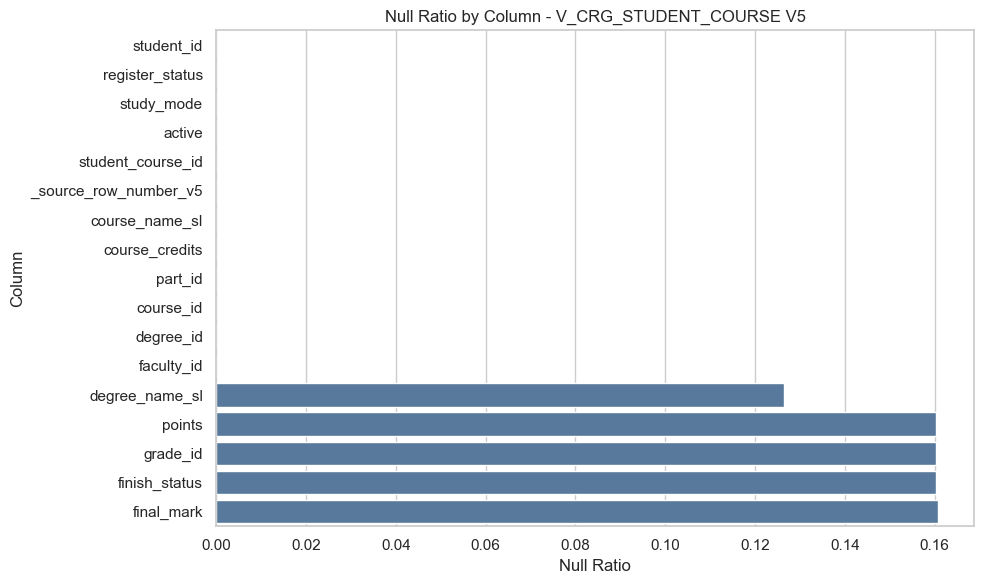

In [10]:
plot_df = null_report_v5.sort_values("null_ratio", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y="column", x="null_ratio", color="#4C78A8")
plt.title("Null Ratio by Column - V_CRG_STUDENT_COURSE V5")
plt.xlabel("Null Ratio")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

## 5. Save finish_status distribution report

`finish_status` is the only official source for academic outcome. `final_mark >= 50` is not used as pass logic.


In [11]:
finish_status_distribution_v5 = (
    df_raw_v5["finish_status"]
    .astype("string")
    .str.strip()
    .str.upper()
    .fillna("<NULL>")
    .value_counts(dropna=False)
    .reset_index()
)

finish_status_distribution_v5.columns = ["finish_status_clean", "count"]
finish_status_distribution_v5["row_count"] = len(df_raw_v5)
finish_status_distribution_v5["ratio"] = finish_status_distribution_v5["count"] / len(df_raw_v5)

finish_status_distribution_path_v5 = REPORTS_DIR / "finish_status_distribution_v5.csv"
finish_status_distribution_v5.to_csv(
    finish_status_distribution_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(finish_status_distribution_v5)
print("Saved:", finish_status_distribution_path_v5)

,finish_status_clean,count,row_count,ratio
0,P,618606,965467,0.640732
1,<NULL>,154773,965467,0.160309
2,F,96787,965467,0.100249
3,W,35982,965467,0.037269
4,T,19525,965467,0.020223
5,Z,13495,965467,0.013978
6,ST,12193,965467,0.012629
7,X,10584,965467,0.010963
8,D,1560,965467,0.001616
9,FA,1105,965467,0.001145


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\finish_status_distribution_v5.csv


In [12]:
assert finish_status_distribution_path_v5.exists()
assert finish_status_distribution_v5["count"].sum() == len(df_raw_v5)

print("Validation passed: finish_status distribution saved.")

Validation passed: finish_status distribution saved.


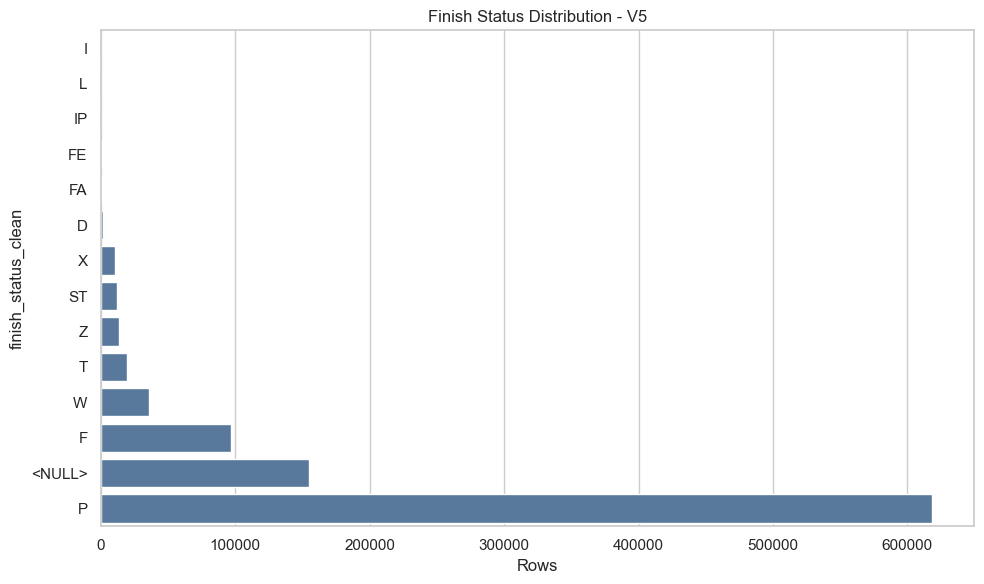

In [13]:
plot_df = finish_status_distribution_v5.sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    y="finish_status_clean",
    x="count",
    color="#4C78A8",
)
plt.title("Finish Status Distribution - V5")
plt.xlabel("Rows")
plt.ylabel("finish_status_clean")
plt.tight_layout()
plt.show()

## 6. Numeric validation without stopping the notebook

Rules:
- `final_mark` should be integer-like.
- `course_credits` can be integer-like or fractional; fractional values are not rounded.
- Fractional `course_credits` are reported for inspection only.
- `points` remains float/raw and is inspected only.


In [14]:
def is_integer_like_numeric(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    return numeric.notna() & ((numeric % 1) == 0)


def integer_like_report(df: pd.DataFrame, column: str) -> dict:
    numeric = pd.to_numeric(df[column], errors="coerce")
    non_null_numeric = numeric.dropna()
    fractional_mask = numeric.notna() & ~is_integer_like_numeric(df[column])
    
    return {
        "column": column,
        "source_dtype": str(df[column].dtype),
        "non_null_count": int(df[column].notna().sum()),
        "numeric_count": int(non_null_numeric.shape[0]),
        "non_numeric_or_null_count": int(df[column].shape[0] - non_null_numeric.shape[0]),
        "fractional_count": int(fractional_mask.sum()),
        "fractional_ratio": float(fractional_mask.sum() / len(non_null_numeric)) if len(non_null_numeric) > 0 else 0,
    }

numeric_validation_report_v5 = pd.DataFrame([
    integer_like_report(df_raw_v5, "final_mark"),
    integer_like_report(df_raw_v5, "course_credits"),
])

points_numeric_v5 = pd.to_numeric(df_raw_v5["points"], errors="coerce")

points_report_v5 = pd.DataFrame([{
    "column": "points",
    "source_dtype": str(df_raw_v5["points"].dtype),
    "non_null_count": int(df_raw_v5["points"].notna().sum()),
    "numeric_count": int(points_numeric_v5.notna().sum()),
    "non_numeric_or_null_count": int(df_raw_v5["points"].shape[0] - points_numeric_v5.notna().sum()),
    "fractional_count": np.nan,
    "fractional_ratio": np.nan,
}])

numeric_validation_report_v5 = pd.concat(
    [numeric_validation_report_v5, points_report_v5],
    ignore_index=True
)

numeric_validation_report_path_v5 = REPORTS_DIR / "numeric_validation_report_v5.csv"
numeric_validation_report_v5.to_csv(
    numeric_validation_report_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(numeric_validation_report_v5)
print("Saved:", numeric_validation_report_path_v5)

,column,source_dtype,non_null_count,numeric_count,non_numeric_or_null_count,fractional_count,fractional_ratio
0,final_mark,float64,810285,810285,155182,0.0,0.000000
1,course_credits,float64,965466,965466,1,9407.0,0.009743
2,points,float64,810711,810711,154756,NaN,NaN


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\numeric_validation_report_v5.csv


In [15]:
final_mark_fractional_v5 = numeric_validation_report_v5.loc[
    numeric_validation_report_v5["column"].eq("final_mark"),
    "fractional_count"
].iloc[0]

course_credits_fractional_v5 = numeric_validation_report_v5.loc[
    numeric_validation_report_v5["column"].eq("course_credits"),
    "fractional_count"
].iloc[0]

assert final_mark_fractional_v5 == 0, "final_mark has fractional values."

if course_credits_fractional_v5 > 0:
    print("WARNING: course_credits has fractional values.")
    print("These rows are valid audit cases and will not be dropped only for being fractional.")
else:
    print("course_credits is integer-like.")

assert numeric_validation_report_path_v5.exists()

print("Validation passed: numeric columns inspected.")

These rows are valid audit cases and will not be dropped only for being fractional.
Validation passed: numeric columns inspected.


## 7. Inspect fractional course_credits

Fractional `course_credits` rows are saved for inspection. They will not enter `df_clean_attempts_v5`.


In [16]:
course_credits_numeric_v5 = pd.to_numeric(df_raw_v5["course_credits"], errors="coerce")

fractional_course_credits_mask_v5 = (
    course_credits_numeric_v5.notna()
    & ((course_credits_numeric_v5 % 1) != 0)
)

fractional_course_credits_rows_v5 = df_raw_v5[fractional_course_credits_mask_v5].copy()

fractional_course_credits_distribution_v5 = (
    fractional_course_credits_rows_v5["course_credits"]
    .value_counts(dropna=False)
    .reset_index()
)

fractional_course_credits_distribution_v5.columns = ["course_credits", "count"]
fractional_course_credits_distribution_v5["row_count"] = len(df_raw_v5)
fractional_course_credits_distribution_v5["ratio"] = (
    fractional_course_credits_distribution_v5["count"] / len(df_raw_v5)
)

fractional_course_credits_rows_path_v5 = REPORTS_DIR / "fractional_course_credits_rows_v5.csv"
fractional_course_credits_distribution_path_v5 = (
    REPORTS_DIR / "fractional_course_credits_distribution_v5.csv"
)

fractional_course_credits_rows_v5.to_csv(
    fractional_course_credits_rows_path_v5,
    index=False,
    encoding="utf-8-sig"
)

fractional_course_credits_distribution_v5.to_csv(
    fractional_course_credits_distribution_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(fractional_course_credits_distribution_v5)
display(fractional_course_credits_rows_v5.head(50))

print("Fractional course_credits rows:", len(fractional_course_credits_rows_v5))
print("Saved:", fractional_course_credits_rows_path_v5)
print("Saved:", fractional_course_credits_distribution_path_v5)

,course_credits,count,row_count,ratio
0,4.5,9407,965467,0.009743


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,register_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5
47840,845319.111,3617.111,705.111,20141.0,984.111,53.0,1.50,P,R,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A,47841
47841,845320.111,3617.111,704.111,20141.0,981.111,66.0,2.25,P,R,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A,47842
58002,861992.111,3625.111,704.111,20141.0,980.111,74.0,2.50,P,R,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A,58003
58003,861993.111,3625.111,705.111,20141.0,982.111,61.0,2.00,P,R,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A,58004
58007,861997.111,3599.111,704.111,20141.0,981.111,68.0,2.25,P,R,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A,58008
58008,861998.111,3599.111,705.111,20141.0,982.111,63.0,2.00,P,R,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A,58009
58020,863050.111,3541.111,705.111,20141.0,985.111,42.0,0.00,F,R,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A,58021
58021,863051.111,3541.111,704.111,20141.0,984.111,50.0,1.50,P,R,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A,58022
58027,863057.111,3356.111,705.111,20141.0,985.111,43.0,0.00,F,R,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A,58028
58028,863058.111,3356.111,704.111,20141.0,985.111,39.0,0.00,F,R,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A,58029


Fractional course_credits rows: 9407
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\fractional_course_credits_rows_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\fractional_course_credits_distribution_v5.csv


In [17]:
assert fractional_course_credits_rows_path_v5.exists()
assert fractional_course_credits_distribution_path_v5.exists()

print("Validation passed: fractional course_credits rows reported.")

Validation passed: fractional course_credits rows reported.


## 8. Drop exact duplicate rows from working dataframe

Raw data remains unchanged in `df_raw_v5`.
Exact duplicates are detected using source business columns only, not `_source_row_number_v5`.


In [18]:
duplicate_full_row_mask_v5 = df_raw_v5.duplicated(
    subset=required_raw_columns_v5,
    keep="first"
)

df_duplicate_rows_v5 = df_raw_v5[duplicate_full_row_mask_v5].copy()

duplicate_rows_path_v5 = REPORTS_DIR / "duplicate_rows_v5.csv"
df_duplicate_rows_v5.to_csv(duplicate_rows_path_v5, index=False, encoding="utf-8-sig")

df_work_v5 = df_raw_v5.drop_duplicates(
    subset=required_raw_columns_v5,
    keep="first"
).copy()

print("Raw rows before duplicate removal:", len(df_raw_v5))
print("Exact duplicate rows removed:", len(df_duplicate_rows_v5))
print("Rows after duplicate removal:", len(df_work_v5))
print("Saved:", duplicate_rows_path_v5)

display(df_duplicate_rows_v5.head(50))

Raw rows before duplicate removal: 965467
Exact duplicate rows removed: 5292
Rows after duplicate removal: 960175
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\duplicate_rows_v5.csv


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,register_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5
370145,1324400.111,14858.111,1162.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 3,C,22.111,إدارة (اختصاص عام),7.111,0.0,A,370146
370147,1324401.111,13993.111,1160.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 1,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A,370148
370149,1324402.111,14643.111,1160.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 1,C,2.111,دكتور في الطب,2.111,0.0,A,370150
370151,1324403.111,14669.111,1160.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 1,C,2.111,دكتور في الطب,2.111,0.0,A,370152
370153,1324404.111,14669.111,1161.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 2,C,2.111,دكتور في الطب,2.111,0.0,A,370154
370155,1324405.111,14669.111,1162.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 3,C,2.111,دكتور في الطب,2.111,0.0,A,370156
370157,1324406.111,14658.111,1160.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 1,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A,370158
370159,1324407.111,14706.111,1160.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 1,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A,370160
370161,1324408.111,14706.111,1161.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 2,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A,370162
370163,1324409.111,14706.111,1162.111,20192.0,1004.111,0.0,0.0,X,X,الانكليزية التحضيرية 3,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A,370164


In [19]:
assert len(df_work_v5) + len(df_duplicate_rows_v5) == len(df_raw_v5)
assert df_work_v5.duplicated(subset=required_raw_columns_v5).sum() == 0
assert duplicate_rows_path_v5.exists()

print("Validation passed: exact duplicates reported and removed from working dataframe.")

Validation passed: exact duplicates reported and removed from working dataframe.


## 9. Define business rules

Current decisions:
- Clean statuses: `P`, `F`, `FA`, `FE`, `W`.
- Archive/drop statuses: `T`, `X`, `IP`, `L`, `Z`, `D`, `I`, `ST`, and null status.
- `F`, `FA`, `FE` are treated as one fail family.
- `course_credits == 0`, `course_credits == 24`, and fractional credits are excluded from clean attempts.


In [20]:
KEEP_STATUSES_V5 = {"P", "F", "FA", "FE", "W"}
PASS_STATUSES_V5 = {"P"}
FAIL_STATUSES_V5 = {"F", "FA", "FE"}
WITHDRAWN_STATUSES_V5 = {"W"}
DROP_ARCHIVE_STATUSES_V5 = {"T", "X", "IP", "L", "Z", "D", "I", "ST"}
FINAL_MARK_ZERO_FILL_STATUSES_V5 = {"F", "FA", "FE", "W", "IP", "Z"}
REGISTER_STATUS_KEEP_STATUSES_V5 = {"E", "R"}
DROP_ZERO_COURSE_CREDITS_V5 = True

KNOWN_STATUSES_V5 = KEEP_STATUSES_V5 | DROP_ARCHIVE_STATUSES_V5

print("Keep statuses:", sorted(KEEP_STATUSES_V5))
print("Pass statuses:", sorted(PASS_STATUSES_V5))
print("Fail statuses:", sorted(FAIL_STATUSES_V5))
print("Withdrawn statuses:", sorted(WITHDRAWN_STATUSES_V5))
print("Archive/drop statuses:", sorted(DROP_ARCHIVE_STATUSES_V5))
print("Final mark zero-fill statuses:", sorted(FINAL_MARK_ZERO_FILL_STATUSES_V5))
print("Register statuses kept in logical duplicate groups:", sorted(REGISTER_STATUS_KEEP_STATUSES_V5))
print("DROP_ZERO_COURSE_CREDITS_V5:", DROP_ZERO_COURSE_CREDITS_V5)

Keep statuses: ['F', 'FA', 'FE', 'P', 'W']
Pass statuses: ['P']
Fail statuses: ['F', 'FA', 'FE']
Withdrawn statuses: ['W']
Archive/drop statuses: ['D', 'I', 'IP', 'L', 'ST', 'T', 'X', 'Z']
Final mark zero-fill statuses: ['F', 'FA', 'FE', 'IP', 'W', 'Z']
Register statuses kept in logical duplicate groups: ['E', 'R']
DROP_ZERO_COURSE_CREDITS_V5: True


In [21]:
assert KEEP_STATUSES_V5 == {"P", "F", "FA", "FE", "W"}
assert PASS_STATUSES_V5 == {"P"}
assert FAIL_STATUSES_V5 == {"F", "FA", "FE"}
assert "IP" in DROP_ARCHIVE_STATUSES_V5
assert REGISTER_STATUS_KEEP_STATUSES_V5 == {"E", "R"}
assert DROP_ZERO_COURSE_CREDITS_V5 is True

print("Validation passed: business rules defined.")

Validation passed: business rules defined.


## 10. Define ID normalization helpers

For each ID column, create:
- `*_raw`
- `*_base`
- `*_suffix`
- `*_key`

Original ID values are not overwritten.


In [22]:
ID_COLUMNS_V5 = [
    "student_course_id",
    "student_id",
    "course_id",
    "part_id",
    "grade_id",
    "degree_id",
    "faculty_id",
]


def normalize_id_to_string(value):
    if pd.isna(value):
        return pd.NA
    
    text = str(value).strip()
    
    if text == "" or text.lower() in {"nan", "none", "null", "<na>"}:
        return pd.NA
    
    try:
        decimal_value = Decimal(text)
        normalized = format(decimal_value, "f")
        
        if "." in normalized:
            normalized = normalized.rstrip("0").rstrip(".")
        
        return normalized
    
    except InvalidOperation:
        return text


def add_id_components(df: pd.DataFrame, id_col: str) -> pd.DataFrame:
    result = df.copy()
    
    raw_col = f"{id_col}_raw"
    str_col = f"{id_col}_str"
    base_col = f"{id_col}_base"
    suffix_col = f"{id_col}_suffix"
    key_col = f"{id_col}_key"
    
    result[raw_col] = result[id_col]
    result[str_col] = result[id_col].apply(normalize_id_to_string).astype("string")
    
    split_parts = result[str_col].str.split(".", n=1, expand=True)
    
    result[base_col] = pd.to_numeric(split_parts[0], errors="coerce").astype("Int64")
    
    if split_parts.shape[1] > 1:
        result[suffix_col] = split_parts[1].astype("string")
    else:
        result[suffix_col] = pd.Series(pd.NA, index=result.index, dtype="string")
    
    result[key_col] = result[str_col]
    
    return result

print("ID columns:", ID_COLUMNS_V5)

ID columns: ['student_course_id', 'student_id', 'course_id', 'part_id', 'grade_id', 'degree_id', 'faculty_id']


In [23]:
for col in ID_COLUMNS_V5:
    assert col in df_work_v5.columns, f"Missing ID column: {col}"

assert normalize_id_to_string(20111.0) == "20111"
assert normalize_id_to_string("20111.000") == "20111"
assert normalize_id_to_string(4.0) == "4"
assert normalize_id_to_string("1491.111") == "1491.111"

id_normalization_check_v5 = add_id_components(
    pd.DataFrame({"part_id": ["20111.0", "1491.111"]}),
    "part_id",
)
assert id_normalization_check_v5.loc[0, "part_id_key"] == "20111"
assert pd.isna(id_normalization_check_v5.loc[0, "part_id_suffix"])
assert id_normalization_check_v5.loc[1, "part_id_key"] == "1491.111"
assert id_normalization_check_v5.loc[1, "part_id_suffix"] == "111"

print("Validation passed: ID normalization helpers ready.")

Validation passed: ID normalization helpers ready.


## 11. Create df_attempts_normalized_v5 base

This dataframe starts from the duplicate-free working dataframe and adds normalized IDs and cleaned helper columns.


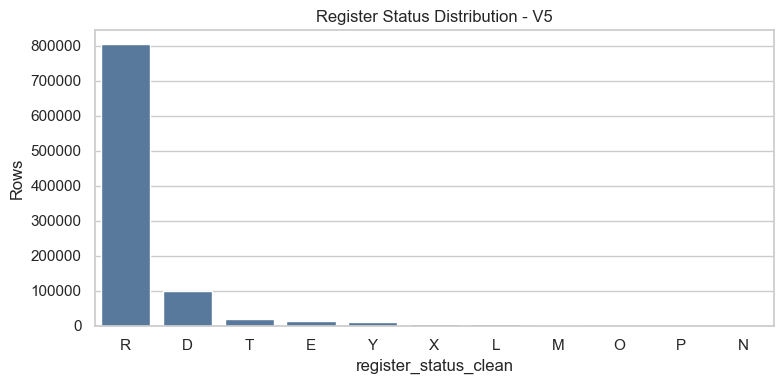

,register_status_clean,count,row_count,ratio
0,R,803324,960175,0.836643
1,D,99716,960175,0.103852
2,T,19525,960175,0.020335
3,E,14675,960175,0.015284
4,Y,10725,960175,0.01117
5,X,5292,960175,0.005511
6,L,4411,960175,0.004594
7,M,2194,960175,0.002285
8,O,247,960175,0.000257
9,P,41,960175,0.000043


,metric,count
0,duplicate_student_course_id_rows_archived,0
1,logical_duplicate_groups_student_course_part,22732
2,non_e_or_r_logical_duplicate_rows_archived,33272
3,groups_with_multiple_e_or_r_rows,0
4,suspicious_multiple_e_or_r_rows,0


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,register_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5,student_course_id_raw,student_course_id_str,student_course_id_base,student_course_id_suffix,student_course_id_key,student_id_raw,student_id_str,student_id_base,student_id_suffix,student_id_key,course_id_raw,course_id_str,course_id_base,course_id_suffix,course_id_key,part_id_raw,part_id_str,part_id_base,part_id_suffix,part_id_key,grade_id_raw,grade_id_str,grade_id_base,grade_id_suffix,grade_id_key,degree_id_raw,degree_id_str,degree_id_base,degree_id_suffix,degree_id_key,faculty_id_raw,faculty_id_str,faculty_id_base,faculty_id_suffix,faculty_id_key,finish_status_clean,register_status_clean,is_registered_request_v5,is_exam_only_request_v5,is_removed_request_v5,is_kept_register_status_v5,final_mark_raw_numeric_v5,final_mark_is_null_v5,final_mark_clean_v5,final_mark_was_filled_zero_v5,final_mark_clean_int_v5,points_float,course_credits_num,has_fractional_course_credits,course_credits_int,course_name_clean,degree_name_clean,study_mode_clean,active_clean,points_source_verified_v5


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,register_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5,student_course_id_raw,student_course_id_str,student_course_id_base,student_course_id_suffix,student_course_id_key,student_id_raw,student_id_str,student_id_base,student_id_suffix,student_id_key,course_id_raw,course_id_str,course_id_base,course_id_suffix,course_id_key,part_id_raw,part_id_str,part_id_base,part_id_suffix,part_id_key,grade_id_raw,grade_id_str,grade_id_base,grade_id_suffix,grade_id_key,degree_id_raw,degree_id_str,degree_id_base,degree_id_suffix,degree_id_key,faculty_id_raw,faculty_id_str,faculty_id_base,faculty_id_suffix,faculty_id_key,finish_status_clean,register_status_clean,is_registered_request_v5,is_exam_only_request_v5,is_removed_request_v5,is_kept_register_status_v5,final_mark_raw_numeric_v5,final_mark_is_null_v5,final_mark_clean_v5,final_mark_was_filled_zero_v5,final_mark_clean_int_v5,points_float,course_credits_num,has_fractional_course_credits,course_credits_int,course_name_clean,degree_name_clean,study_mode_clean,active_clean,points_source_verified_v5,is_logical_duplicate_group_v5,register_status_non_er_logical_duplicate_drop_v5,is_register_status_archive_drop_v5,is_register_status_multiple_kept_review_v5


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\register_status_distribution_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\register_status_duplicate_resolution_report_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\duplicate_student_course_id_rows_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\logical_duplicate_registered_rows_v5.csv


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,register_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5,student_course_id_raw,student_course_id_str,student_course_id_base,student_course_id_suffix,student_course_id_key,student_id_raw,student_id_str,student_id_base,student_id_suffix,student_id_key,course_id_raw,course_id_str,course_id_base,course_id_suffix,course_id_key,part_id_raw,part_id_str,part_id_base,part_id_suffix,part_id_key,grade_id_raw,grade_id_str,grade_id_base,grade_id_suffix,grade_id_key,degree_id_raw,degree_id_str,degree_id_base,degree_id_suffix,degree_id_key,faculty_id_raw,faculty_id_str,faculty_id_base,faculty_id_suffix,faculty_id_key,finish_status_clean,register_status_clean,is_registered_request_v5,is_exam_only_request_v5,is_removed_request_v5,is_kept_register_status_v5,final_mark_raw_numeric_v5,final_mark_is_null_v5,final_mark_clean_v5,final_mark_was_filled_zero_v5,final_mark_clean_int_v5,points_float,course_credits_num,has_fractional_course_credits,course_credits_int,course_name_clean,degree_name_clean,study_mode_clean,active_clean,points_source_verified_v5,is_logical_duplicate_group_v5,register_status_non_er_logical_duplicate_drop_v5,is_register_status_archive_drop_v5,is_register_status_multiple_kept_review_v5
0,466289.111,1491.111,153.111,20111.0,684.111,37.0,0.00,F,R,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A,1,466289.111,466289.111,466289,111,466289.111,1491.111,1491.111,1491,111,1491.111,153.111,153.111,153,111,153.111,20111.0,20111,20111,<NA>,20111,684.111,684.111,684,111,684.111,19.111,19.111,19,111,19.111,7.111,7.111,7,111,7.111,F,R,True,False,False,True,37.0,False,37.0,False,37,0.00,2.0,False,2,التحليل الاقتصادي الجزئي,إدارة الأعمال,C,A,False,False,False,False,False
1,466290.111,1491.111,152.111,20111.0,684.111,48.0,0.00,F,R,مدخل الى القانون,C,19.111,إدارة الأعمال,7.111,2.0,A,2,466290.111,466290.111,466290,111,466290.111,1491.111,1491.111,1491,111,1491.111,152.111,152.111,152,111,152.111,20111.0,20111,20111,<NA>,20111,684.111,684.111,684,111,684.111,19.111,19.111,19,111,19.111,7.111,7.111,7,111,7.111,F,R,True,False,False,True,48.0,False,48.0,False,48,0.00,2.0,False,2,مدخل الى القانون,إدارة الأعمال,C,A,False,False,False,False,False
2,466291.111,1491.111,150.111,20111.0,679.111,72.0,2.50,P,R,مهارات الحاسوب 1,C,19.111,إدارة الأعمال,7.111,3.0,A,3,466291.111,466291.111,466291,111,466291.111,1491.111,1491.111,1491,111,1491.111,150.111,150.111,150,111,150.111,20111.0,20111,20111,<NA>,20111,679.111,679.111,679,111,679.111,19.111,19.111,19,111,19.111,7.111,7.111,7,111,7.111,P,R,True,False,False,True,72.0,False,72.0,False,72,2.50,3.0,False,3,مهارات الحاسوب 1,إدارة الأعمال,C,A,False,False,False,False,False
3,466292.111,1491.111,149.111,20111.0,676.111,86.0,3.25,P,R,اللغة العربية,C,19.111,إدارة الأعمال,7.111,2.0,A,4,466292.111,466292.111,466292,111,466292.111,1491.111,1491.111,1491,111,1491.111,149.111,149.111,149,111,149.111,20111.0,20111,20111,<NA>,20111,676.111,676.111,676,111,676.111,19.111,19.111,19,111,19.111,7.111,7.111,7,111,7.111,P,R,True,False,False,True,86.0,False,86.0,False,86,3.25,2.0,False,2,اللغة العربية,إدارة الأعمال,C,A,False,False,False,False,False
4,466293.111,1492.111,153.111,20111.0,684.111,12.0,0.00,F,R,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A,5,466293.111,466293.111,466293,111,466293.111,1492.111,1492.111,1492,111,1492.111,153.111,153.111,153,111,153.111,20111.0,20111,20111,<NA>,20111,684.111,684.111,684,111,684.111,19.111,19.111,19,111,19.111,7.111,7.111,7,111,7.111,F,R,True,False,False,True,12.0,False,12.0,False,12,0.00,2.0,False,2,التحليل الاقتصادي الجزئي,إدارة الأعمال,C,A,False,False,False,False,False


In [24]:
df_attempts_normalized_v5 = df_work_v5.copy()

for id_col in ID_COLUMNS_V5:
    df_attempts_normalized_v5 = add_id_components(df_attempts_normalized_v5, id_col)

# Standardized text / numeric helper columns.
df_attempts_normalized_v5["finish_status_clean"] = (
    df_attempts_normalized_v5["finish_status"]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_attempts_normalized_v5["register_status_clean"] = (
    df_attempts_normalized_v5["register_status"]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_attempts_normalized_v5["register_status_clean"] = (
    df_attempts_normalized_v5["register_status_clean"]
    .mask(df_attempts_normalized_v5["register_status_clean"].str.len().fillna(0).eq(0))
)

df_attempts_normalized_v5["is_registered_request_v5"] = (
    df_attempts_normalized_v5["register_status_clean"].eq("R")
    .fillna(False)
)

df_attempts_normalized_v5["is_exam_only_request_v5"] = (
    df_attempts_normalized_v5["register_status_clean"].eq("E")
    .fillna(False)
)

df_attempts_normalized_v5["is_removed_request_v5"] = (
    df_attempts_normalized_v5["register_status_clean"].eq("D")
    .fillna(False)
)

df_attempts_normalized_v5["is_kept_register_status_v5"] = (
    df_attempts_normalized_v5["register_status_clean"]
    .isin(REGISTER_STATUS_KEEP_STATUSES_V5)
    .fillna(False)
)

df_attempts_normalized_v5["final_mark_raw_numeric_v5"] = pd.to_numeric(
    df_attempts_normalized_v5["final_mark"],
    errors="coerce"
)

df_attempts_normalized_v5["final_mark_is_null_v5"] = (
    df_attempts_normalized_v5["final_mark_raw_numeric_v5"].isna()
)

df_attempts_normalized_v5["final_mark_clean_v5"] = (
    df_attempts_normalized_v5["final_mark_raw_numeric_v5"].copy()
)

df_attempts_normalized_v5["final_mark_was_filled_zero_v5"] = (
    df_attempts_normalized_v5["final_mark_clean_v5"].isna()
    & df_attempts_normalized_v5["finish_status_clean"].isin(FINAL_MARK_ZERO_FILL_STATUSES_V5)
)

df_attempts_normalized_v5.loc[
    df_attempts_normalized_v5["final_mark_was_filled_zero_v5"],
    "final_mark_clean_v5"
] = 0

df_attempts_normalized_v5["final_mark_clean_int_v5"] = (
    df_attempts_normalized_v5["final_mark_clean_v5"]
    .round()
    .astype("Int64")
)

df_attempts_normalized_v5["points_float"] = pd.to_numeric(
    df_attempts_normalized_v5["points"],
    errors="coerce"
).astype("float64")

df_attempts_normalized_v5["course_credits_num"] = pd.to_numeric(
    df_attempts_normalized_v5["course_credits"],
    errors="coerce"
).astype("float64")

df_attempts_normalized_v5["has_fractional_course_credits"] = (
    df_attempts_normalized_v5["course_credits_num"].notna()
    & ((df_attempts_normalized_v5["course_credits_num"] % 1) != 0)
)

course_credits_integer_like_mask_v5 = is_integer_like_numeric(
    df_attempts_normalized_v5["course_credits_num"]
)

df_attempts_normalized_v5["course_credits_int"] = pd.Series(
    np.where(
        course_credits_integer_like_mask_v5,
        df_attempts_normalized_v5["course_credits_num"],
        np.nan,
    ),
    index=df_attempts_normalized_v5.index,
).astype("Int64")

df_attempts_normalized_v5["course_name_clean"] = (
    df_attempts_normalized_v5["course_name_sl"]
    .astype("string")
    .str.strip()
)

df_attempts_normalized_v5["degree_name_clean"] = (
    df_attempts_normalized_v5["degree_name_sl"]
    .astype("string")
    .str.strip()
)

df_attempts_normalized_v5["study_mode_clean"] = (
    df_attempts_normalized_v5["study_mode"]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_attempts_normalized_v5["active_clean"] = (
    df_attempts_normalized_v5["active"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Grade and points are kept as raw/unverified until grade version metadata is joined later.
df_attempts_normalized_v5["points_source_verified_v5"] = False

register_status_distribution_v5 = (
    df_attempts_normalized_v5["register_status_clean"]
    .fillna("<NULL>")
    .value_counts(dropna=False)
    .reset_index()
)
register_status_distribution_v5.columns = ["register_status_clean", "count"]
register_status_distribution_v5["row_count"] = len(df_attempts_normalized_v5)
register_status_distribution_v5["ratio"] = (
    register_status_distribution_v5["count"] / len(df_attempts_normalized_v5)
)

logical_duplicate_key_cols_v5 = ["student_id_key", "course_id_key", "part_id_key"]

duplicate_student_course_id_mask_v5 = (
    df_attempts_normalized_v5["student_course_id_key"].notna()
    & df_attempts_normalized_v5.duplicated(
        subset=["student_course_id_key"],
        keep="first",
    )
)

duplicate_student_course_id_rows_v5 = df_attempts_normalized_v5[
    duplicate_student_course_id_mask_v5
].copy()

register_status_grouped_v5 = df_attempts_normalized_v5.groupby(
    logical_duplicate_key_cols_v5,
    dropna=False,
)
register_group_row_count_v5 = register_status_grouped_v5["student_course_id_key"].transform("size")
register_group_kept_count_v5 = register_status_grouped_v5["is_kept_register_status_v5"].transform("sum")

df_attempts_normalized_v5["is_logical_duplicate_group_v5"] = (
    register_group_row_count_v5.gt(1)
)

df_attempts_normalized_v5["register_status_non_er_logical_duplicate_drop_v5"] = (
    df_attempts_normalized_v5["is_logical_duplicate_group_v5"]
    & ~df_attempts_normalized_v5["is_kept_register_status_v5"]
)

df_attempts_normalized_v5["is_register_status_archive_drop_v5"] = (
    df_attempts_normalized_v5["register_status_non_er_logical_duplicate_drop_v5"]
)

df_attempts_normalized_v5["is_register_status_multiple_kept_review_v5"] = (
    df_attempts_normalized_v5["is_logical_duplicate_group_v5"]
    & df_attempts_normalized_v5["is_kept_register_status_v5"]
    & register_group_kept_count_v5.gt(1)
)

register_status_group_summary_v5 = (
    df_attempts_normalized_v5
    .groupby(logical_duplicate_key_cols_v5, dropna=False)
    .agg(
        row_count=("student_course_id_key", "size"),
        kept_register_status_count=("is_kept_register_status_v5", "sum"),
        r_count=("is_registered_request_v5", "sum"),
        e_count=("is_exam_only_request_v5", "sum"),
        d_count=("is_removed_request_v5", "sum"),
    )
    .reset_index()
)

logical_duplicate_registered_rows_v5 = df_attempts_normalized_v5[
    df_attempts_normalized_v5["is_register_status_multiple_kept_review_v5"]
].copy()

register_status_duplicate_resolution_report_v5 = pd.DataFrame([
    {
        "metric": "duplicate_student_course_id_rows_archived",
        "count": len(duplicate_student_course_id_rows_v5),
    },
    {
        "metric": "logical_duplicate_groups_student_course_part",
        "count": int(register_status_group_summary_v5["row_count"].gt(1).sum()),
    },
    {
        "metric": "non_e_or_r_logical_duplicate_rows_archived",
        "count": int(df_attempts_normalized_v5["register_status_non_er_logical_duplicate_drop_v5"].sum()),
    },
    {
        "metric": "groups_with_multiple_e_or_r_rows",
        "count": int(register_status_group_summary_v5["kept_register_status_count"].gt(1).sum()),
    },
    {
        "metric": "suspicious_multiple_e_or_r_rows",
        "count": len(logical_duplicate_registered_rows_v5),
    },
])

register_status_distribution_path_v5 = REPORTS_DIR / "register_status_distribution_v5.csv"
register_status_duplicate_resolution_report_path_v5 = (
    REPORTS_DIR / "register_status_duplicate_resolution_report_v5.csv"
)
duplicate_student_course_id_rows_path_v5 = (
    REPORTS_DIR / "duplicate_student_course_id_rows_v5.csv"
)
logical_duplicate_registered_rows_path_v5 = (
    REPORTS_DIR / "logical_duplicate_registered_rows_v5.csv"
)

register_status_distribution_v5.to_csv(
    register_status_distribution_path_v5,
    index=False,
    encoding="utf-8-sig",
)
register_status_duplicate_resolution_report_v5.to_csv(
    register_status_duplicate_resolution_report_path_v5,
    index=False,
    encoding="utf-8-sig",
)
duplicate_student_course_id_rows_v5.to_csv(
    duplicate_student_course_id_rows_path_v5,
    index=False,
    encoding="utf-8-sig",
)
logical_duplicate_registered_rows_v5.to_csv(
    logical_duplicate_registered_rows_path_v5,
    index=False,
    encoding="utf-8-sig",
)

register_plot_df_v5 = register_status_distribution_v5.sort_values("count", ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(
    data=register_plot_df_v5,
    x="register_status_clean",
    y="count",
    color="#4C78A8",
)
plt.title("Register Status Distribution - V5")
plt.xlabel("register_status_clean")
plt.ylabel("Rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(register_status_distribution_v5)
display(register_status_duplicate_resolution_report_v5)
display(duplicate_student_course_id_rows_v5.head(50))
display(logical_duplicate_registered_rows_v5.head(50))
print("Saved:", register_status_distribution_path_v5)
print("Saved:", register_status_duplicate_resolution_report_path_v5)
print("Saved:", duplicate_student_course_id_rows_path_v5)
print("Saved:", logical_duplicate_registered_rows_path_v5)

display(df_attempts_normalized_v5.head())

In [25]:
for id_col in ID_COLUMNS_V5:
    assert id_col in df_attempts_normalized_v5.columns
    assert f"{id_col}_raw" in df_attempts_normalized_v5.columns
    assert f"{id_col}_base" in df_attempts_normalized_v5.columns
    assert f"{id_col}_suffix" in df_attempts_normalized_v5.columns
    assert f"{id_col}_key" in df_attempts_normalized_v5.columns
    assert df_attempts_normalized_v5[id_col].equals(df_attempts_normalized_v5[f"{id_col}_raw"])

assert len(df_attempts_normalized_v5) == len(df_work_v5)
assert "_source_row_number_v5" in df_attempts_normalized_v5.columns
assert "part_id_base" in df_attempts_normalized_v5.columns
assert "register_status" in df_attempts_normalized_v5.columns
assert "register_status_clean" in df_attempts_normalized_v5.columns
assert "is_registered_request_v5" in df_attempts_normalized_v5.columns
assert "is_exam_only_request_v5" in df_attempts_normalized_v5.columns
assert "is_removed_request_v5" in df_attempts_normalized_v5.columns
assert "is_kept_register_status_v5" in df_attempts_normalized_v5.columns
assert df_attempts_normalized_v5["register_status"].equals(df_work_v5["register_status"])
assert register_status_distribution_path_v5.exists()
assert register_status_duplicate_resolution_report_path_v5.exists()
assert duplicate_student_course_id_rows_path_v5.exists()
assert logical_duplicate_registered_rows_path_v5.exists()
assert register_status_distribution_v5["count"].sum() == len(df_attempts_normalized_v5)
assert df_attempts_normalized_v5.loc[
    df_attempts_normalized_v5["register_status_non_er_logical_duplicate_drop_v5"],
    "register_status_clean",
].isin(REGISTER_STATUS_KEEP_STATUSES_V5).sum() == 0
assert not df_attempts_normalized_v5.loc[
    ~df_attempts_normalized_v5["is_logical_duplicate_group_v5"],
    "is_register_status_archive_drop_v5",
].any()

print("Validation passed: df_attempts_normalized_v5 base created and IDs preserved.")

Validation passed: df_attempts_normalized_v5 base created and IDs preserved.


## 12. Save null-handling and course-credit null reports

These reports document null handling decisions without silently changing raw source columns.
`course_credits` null rows are reported separately and are excluded later through the critical issue flag.


In [26]:
finish_status_null_mask_v5 = df_attempts_normalized_v5["finish_status_clean"].isna()

finish_status_null_without_grade_mark_points_v5 = (
    finish_status_null_mask_v5
    & df_attempts_normalized_v5["grade_id"].isna()
    & df_attempts_normalized_v5["final_mark_raw_numeric_v5"].isna()
    & df_attempts_normalized_v5["points_float"].isna()
)

finish_status_null_with_final_mark_zero_v5 = (
    finish_status_null_mask_v5
    & df_attempts_normalized_v5["final_mark_raw_numeric_v5"].eq(0)
)

course_credits_null_mask_v5 = df_attempts_normalized_v5["course_credits_num"].isna()

course_name_null_mask_v5 = (
    df_attempts_normalized_v5["course_name_clean"].isna()
    | df_attempts_normalized_v5["course_name_clean"].str.len().fillna(0).eq(0)
)

degree_name_null_mask_v5 = (
    df_attempts_normalized_v5["degree_name_clean"].isna()
    | df_attempts_normalized_v5["degree_name_clean"].str.len().fillna(0).eq(0)
)

null_handling_report_v5 = pd.DataFrame([
    {
        "case": "finish_status_null_total_archive_drop",
        "count": int(finish_status_null_mask_v5.sum()),
    },
    {
        "case": "finish_status_null_without_grade_mark_points_archive_drop",
        "count": int(finish_status_null_without_grade_mark_points_v5.sum()),
    },
    {
        "case": "finish_status_null_with_final_mark_zero_archive_drop",
        "count": int(finish_status_null_with_final_mark_zero_v5.sum()),
    },
    {
        "case": "final_mark_null_filled_zero_allowed_statuses",
        "count": int(df_attempts_normalized_v5["final_mark_was_filled_zero_v5"].sum()),
    },
    {
        "case": "course_credits_null_not_filled_critical",
        "count": int(course_credits_null_mask_v5.sum()),
    },
    {
        "case": "course_name_null_audit_only_not_direct_drop",
        "count": int(course_name_null_mask_v5.sum()),
    },
    {
        "case": "degree_name_null_audit_only_not_direct_drop",
        "count": int(degree_name_null_mask_v5.sum()),
    },
])

null_handling_report_v5["row_count"] = len(df_attempts_normalized_v5)
null_handling_report_v5["ratio"] = null_handling_report_v5["count"] / len(df_attempts_normalized_v5)

null_handling_report_path_v5 = REPORTS_DIR / "null_handling_report_v5.csv"
null_handling_report_v5.to_csv(null_handling_report_path_v5, index=False, encoding="utf-8-sig")

course_credits_null_rows_v5 = df_attempts_normalized_v5[course_credits_null_mask_v5].copy()

course_credits_null_rows_path_v5 = REPORTS_DIR / "course_credits_null_rows_v5.csv"
course_credits_null_report_path_v5 = REPORTS_DIR / "course_credits_null_report_v5.csv"

course_credits_null_rows_v5.to_csv(
    course_credits_null_rows_path_v5,
    index=False,
    encoding="utf-8-sig",
)

course_credits_null_report_v5 = pd.DataFrame([{
    "case": "course_credits_null_not_filled_critical",
    "count": len(course_credits_null_rows_v5),
    "row_count": len(df_attempts_normalized_v5),
    "ratio": len(course_credits_null_rows_v5) / len(df_attempts_normalized_v5),
}])

course_credits_null_report_v5.to_csv(
    course_credits_null_report_path_v5,
    index=False,
    encoding="utf-8-sig",
)

display(null_handling_report_v5)
display(course_credits_null_report_v5)
display(course_credits_null_rows_v5.head(50))

print("Saved:", null_handling_report_path_v5)
print("Saved:", course_credits_null_rows_path_v5)
print("Saved:", course_credits_null_report_path_v5)


,case,count,row_count,ratio
0,finish_status_null_total_archive_drop,154773,960175,0.161192
1,finish_status_null_without_grade_mark_points_a...,154673,960175,0.161088
2,finish_status_null_with_final_mark_zero_archiv...,98,960175,0.000102
3,final_mark_null_filled_zero_allowed_statuses,507,960175,0.000528
4,course_credits_null_not_filled_critical,1,960175,0.000001
5,course_name_null_audit_only_not_direct_drop,1,960175,0.000001
6,degree_name_null_audit_only_not_direct_drop,121842,960175,0.126896


,case,count,row_count,ratio
0,course_credits_null_not_filled_critical,1,960175,0.000001


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,register_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5,student_course_id_raw,student_course_id_str,student_course_id_base,student_course_id_suffix,student_course_id_key,student_id_raw,student_id_str,student_id_base,student_id_suffix,student_id_key,course_id_raw,course_id_str,course_id_base,course_id_suffix,course_id_key,part_id_raw,part_id_str,part_id_base,part_id_suffix,part_id_key,grade_id_raw,grade_id_str,grade_id_base,grade_id_suffix,grade_id_key,degree_id_raw,degree_id_str,degree_id_base,degree_id_suffix,degree_id_key,faculty_id_raw,faculty_id_str,faculty_id_base,faculty_id_suffix,faculty_id_key,finish_status_clean,register_status_clean,is_registered_request_v5,is_exam_only_request_v5,is_removed_request_v5,is_kept_register_status_v5,final_mark_raw_numeric_v5,final_mark_is_null_v5,final_mark_clean_v5,final_mark_was_filled_zero_v5,final_mark_clean_int_v5,points_float,course_credits_num,has_fractional_course_credits,course_credits_int,course_name_clean,degree_name_clean,study_mode_clean,active_clean,points_source_verified_v5,is_logical_duplicate_group_v5,register_status_non_er_logical_duplicate_drop_v5,is_register_status_archive_drop_v5,is_register_status_multiple_kept_review_v5
213695,1095624.111,3432.111,NaN,NaN,985.111,0.0,0.0,F,R,NaN,C,2.111,دكتور في الطب,2.111,NaN,A,213696,1095624.111,1095624.111,1095624,111,1095624.111,3432.111,3432.111,3432,111,3432.111,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,985.111,985.111,985,111,985.111,2.111,2.111,2,111,2.111,2.111,2.111,2,111,2.111,F,R,True,False,False,True,0.0,False,0.0,False,0,0.0,NaN,False,<NA>,<NA>,دكتور في الطب,C,A,False,False,False,False,False


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\null_handling_report_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\course_credits_null_rows_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\course_credits_null_report_v5.csv


In [27]:
assert null_handling_report_path_v5.exists()
assert course_credits_null_rows_path_v5.exists()
assert course_credits_null_report_path_v5.exists()

print("Validation passed: null-handling and course-credit null reports saved.")


Validation passed: null-handling and course-credit null reports saved.


## 13. Save ID suffix inspection report

This report checks suffix distribution for all ID columns.


In [28]:
suffix_reports_v5 = []

for id_col in ID_COLUMNS_V5:
    suffix_col = f"{id_col}_suffix"
    
    temp = (
        df_attempts_normalized_v5[suffix_col]
        .fillna("<NO_SUFFIX>")
        .value_counts(dropna=False)
        .reset_index()
    )
    
    temp.columns = ["suffix", "count"]
    temp.insert(0, "id_column", id_col)
    temp["row_count"] = len(df_attempts_normalized_v5)
    temp["ratio"] = temp["count"] / len(df_attempts_normalized_v5)
    
    suffix_reports_v5.append(temp)

id_suffix_report_v5 = pd.concat(suffix_reports_v5, ignore_index=True)

id_suffix_report_path_v5 = REPORTS_DIR / "id_suffix_report_v5.csv"
id_suffix_report_v5.to_csv(id_suffix_report_path_v5, index=False, encoding="utf-8-sig")

display(id_suffix_report_v5)
print("Saved:", id_suffix_report_path_v5)

,id_column,suffix,count,row_count,ratio
0,student_course_id,111,960106,960175,0.999928
1,student_course_id,101,52,960175,0.000054
2,student_course_id,<NO_SUFFIX>,17,960175,0.000018
3,student_id,111,960175,960175,1.0
4,course_id,111,960174,960175,0.999999
5,course_id,<NO_SUFFIX>,1,960175,0.000001
6,part_id,<NO_SUFFIX>,960175,960175,1.0
7,grade_id,111,805419,960175,0.838825
8,grade_id,<NO_SUFFIX>,154756,960175,0.161175
9,degree_id,111,960141,960175,0.999965


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\id_suffix_report_v5.csv


In [29]:
assert id_suffix_report_path_v5.exists()
assert set(id_suffix_report_v5["id_column"]) == set(ID_COLUMNS_V5)

print("Validation passed: ID suffix report saved.")

Validation passed: ID suffix report saved.


## 14. Create academic status flags

These flags are derived only from `finish_status_clean`, never from marks.


In [30]:
df_attempts_normalized_v5["is_official_pass"] = (
    df_attempts_normalized_v5["finish_status_clean"].isin(PASS_STATUSES_V5)
)

df_attempts_normalized_v5["is_fail"] = (
    df_attempts_normalized_v5["finish_status_clean"].isin(FAIL_STATUSES_V5)
)

df_attempts_normalized_v5["is_fail_like"] = (
    df_attempts_normalized_v5["finish_status_clean"].isin({"FA", "FE"})
)

df_attempts_normalized_v5["fail_family_v5"] = (
    df_attempts_normalized_v5["finish_status_clean"].isin(FAIL_STATUSES_V5)
)

df_attempts_normalized_v5["is_withdrawn"] = (
    df_attempts_normalized_v5["finish_status_clean"].isin(WITHDRAWN_STATUSES_V5)
)

# IP is an archive/drop status. It will not enter df_clean_attempts_v5.
# Keep this flag explicit for final clean-table completeness.
df_attempts_normalized_v5["is_in_progress"] = False

df_attempts_normalized_v5["is_internal_performance_attempt"] = (
    df_attempts_normalized_v5["finish_status_clean"].isin(PASS_STATUSES_V5 | FAIL_STATUSES_V5)
)

df_attempts_normalized_v5["is_unknown_finish_status"] = (
    df_attempts_normalized_v5["finish_status_clean"].notna()
    & ~df_attempts_normalized_v5["finish_status_clean"].isin(KNOWN_STATUSES_V5)
)

display(df_attempts_normalized_v5[[
    "finish_status",
    "finish_status_clean",
    "is_official_pass",
    "is_fail",
    "is_fail_like",
    "fail_family_v5",
    "is_withdrawn",
    "is_in_progress",
    "is_internal_performance_attempt",
    "is_unknown_finish_status",
]].head(30))


,finish_status,finish_status_clean,is_official_pass,is_fail,is_fail_like,fail_family_v5,is_withdrawn,is_in_progress,is_internal_performance_attempt,is_unknown_finish_status
0,F,F,False,True,False,True,False,False,True,False
1,F,F,False,True,False,True,False,False,True,False
2,P,P,True,False,False,False,False,False,True,False
3,P,P,True,False,False,False,False,False,True,False
4,F,F,False,True,False,True,False,False,True,False
5,F,F,False,True,False,True,False,False,True,False
6,F,F,False,True,False,True,False,False,True,False
7,F,F,False,True,False,True,False,False,True,False
8,F,F,False,True,False,True,False,False,True,False
9,F,F,False,True,False,True,False,False,True,False


In [31]:
assert not (df_attempts_normalized_v5["is_official_pass"] & df_attempts_normalized_v5["is_fail"]).any()
assert not (df_attempts_normalized_v5["is_withdrawn"] & df_attempts_normalized_v5["is_internal_performance_attempt"]).any()
assert not df_attempts_normalized_v5["is_in_progress"].any()

print("Validation passed: academic status flags are consistent for the clean-attempt design.")


Validation passed: academic status flags are consistent for the clean-attempt design.


## 15. Save study_mode and active audit reports

These fields are not used as drop rules yet, but their distributions are saved for audit.


In [32]:
study_mode_distribution_v5 = (
    df_attempts_normalized_v5["study_mode_clean"]
    .fillna("<NULL>")
    .value_counts(dropna=False)
    .reset_index()
)
study_mode_distribution_v5.columns = ["study_mode_clean", "count"]
study_mode_distribution_v5["row_count"] = len(df_attempts_normalized_v5)
study_mode_distribution_v5["ratio"] = study_mode_distribution_v5["count"] / len(df_attempts_normalized_v5)

active_distribution_v5 = (
    df_attempts_normalized_v5["active_clean"]
    .fillna("<NULL>")
    .value_counts(dropna=False)
    .reset_index()
)
active_distribution_v5.columns = ["active_clean", "count"]
active_distribution_v5["row_count"] = len(df_attempts_normalized_v5)
active_distribution_v5["ratio"] = active_distribution_v5["count"] / len(df_attempts_normalized_v5)

study_mode_distribution_path_v5 = REPORTS_DIR / "study_mode_distribution_v5.csv"
active_distribution_path_v5 = REPORTS_DIR / "active_distribution_v5.csv"

study_mode_distribution_v5.to_csv(study_mode_distribution_path_v5, index=False, encoding="utf-8-sig")
active_distribution_v5.to_csv(active_distribution_path_v5, index=False, encoding="utf-8-sig")

display(study_mode_distribution_v5)
display(active_distribution_v5)
print("Saved:", study_mode_distribution_path_v5)
print("Saved:", active_distribution_path_v5)

,study_mode_clean,count,row_count,ratio
0,C,960175,960175,1.0


,active_clean,count,row_count,ratio
0,A,960175,960175,1.0


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\study_mode_distribution_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\active_distribution_v5.csv


In [33]:
assert study_mode_distribution_path_v5.exists()
assert active_distribution_path_v5.exists()

print("Validation passed: study_mode and active audit reports saved.")

Validation passed: study_mode and active audit reports saved.


## 16. Flag archive/drop rows

Rows are flagged before exclusion. Zero-credit, 24-credit, invalid finish-status, duplicate `student_course_id`, and non-E/R register-status rows inside logical duplicate groups are archived/dropped according to the current decision.

Fractional course credits are valid audit cases and are not archived only for being fractional.


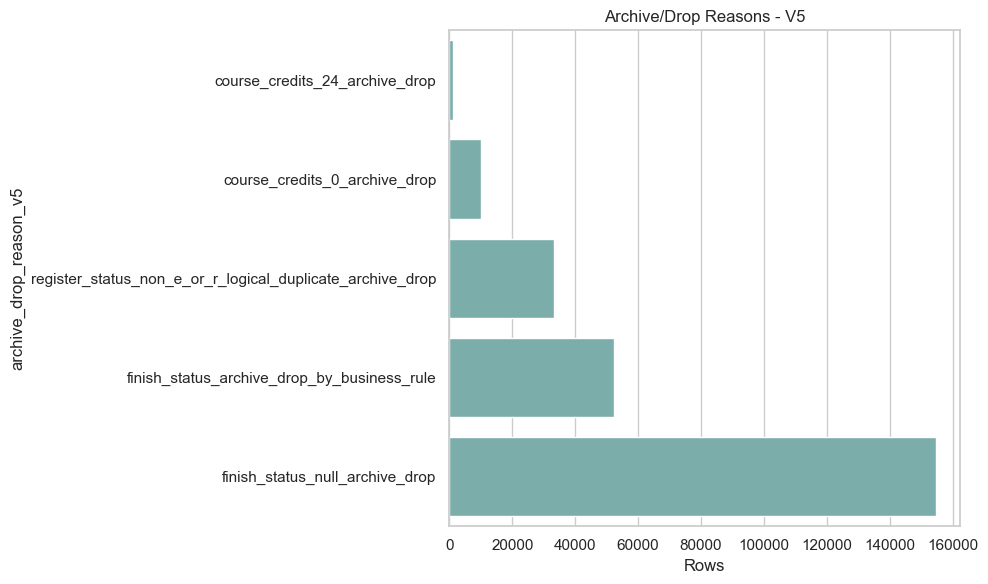

,archive_drop_reason_v5,count,row_count,ratio
0,finish_status_null_archive_drop,154773,960175,0.161192
1,finish_status_archive_drop_by_business_rule,52348,960175,0.054519
2,register_status_non_e_or_r_logical_duplicate_a...,33272,960175,0.034652
3,course_credits_0_archive_drop,9940,960175,0.010352
4,course_credits_24_archive_drop,1209,960175,0.001259


Archive/drop rows: 211280
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\archive_drop_report_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\archive_drop_rows_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\archive_drop_rows_v5.parquet


In [34]:
def append_reason(df: pd.DataFrame, mask: pd.Series, column: str, reason: str) -> None:
    current = df.loc[mask, column].astype("string").fillna("")
    separator = np.where(current.str.len() > 0, " | ", "")
    df.loc[mask, column] = current + separator + reason


df_attempts_normalized_v5["archive_drop_reason_v5"] = ""

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["finish_status_clean"].isna(),
    "archive_drop_reason_v5",
    "finish_status_null_archive_drop",
)

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["finish_status_clean"].isin(DROP_ARCHIVE_STATUSES_V5),
    "archive_drop_reason_v5",
    "finish_status_archive_drop_by_business_rule",
)
### Error 
append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["course_credits_num"].eq(0),
    "archive_drop_reason_v5",
    "course_credits_0_archive_drop",
)

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["course_credits_num"].eq(24),
    "archive_drop_reason_v5",
    "course_credits_24_archive_drop",
)

append_reason(
    df_attempts_normalized_v5,
    duplicate_student_course_id_mask_v5,
    "archive_drop_reason_v5",
    "duplicate_student_course_id_archive_drop",
)

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["register_status_non_er_logical_duplicate_drop_v5"],
    "archive_drop_reason_v5",
    "register_status_non_e_or_r_logical_duplicate_archive_drop",
)

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["is_unknown_finish_status"],
    "archive_drop_reason_v5",
    "unknown_finish_status_review_archive_drop",
)

df_attempts_normalized_v5["is_archive_or_drop"] = (
    df_attempts_normalized_v5["archive_drop_reason_v5"]
    .astype("string")
    .str.len()
    .gt(0)
)

archive_drop_rows_v5 = df_attempts_normalized_v5[
    df_attempts_normalized_v5["is_archive_or_drop"]
].copy()

archive_drop_reason_items_v5 = (
    archive_drop_rows_v5
    .assign(
        archive_drop_reason_v5=lambda df: (
            df["archive_drop_reason_v5"]
            .astype("string")
            .str.split(" | ", regex=False)
        )
    )
    .explode("archive_drop_reason_v5")
)

archive_drop_report_v5 = (
    archive_drop_reason_items_v5["archive_drop_reason_v5"]
    .value_counts(dropna=False)
    .reset_index()
)
archive_drop_report_v5.columns = ["archive_drop_reason_v5", "count"]
archive_drop_report_v5["row_count"] = len(df_attempts_normalized_v5)
archive_drop_report_v5["ratio"] = archive_drop_report_v5["count"] / len(df_attempts_normalized_v5)

archive_drop_report_path_v5 = REPORTS_DIR / "archive_drop_report_v5.csv"
archive_drop_rows_csv_path_v5 = REPORTS_DIR / "archive_drop_rows_v5.csv"
archive_drop_rows_parquet_path_v5 = REPORTS_DIR / "archive_drop_rows_v5.parquet"

archive_drop_report_v5.to_csv(archive_drop_report_path_v5, index=False, encoding="utf-8-sig")
archive_drop_rows_v5.to_csv(archive_drop_rows_csv_path_v5, index=False, encoding="utf-8-sig")
archive_drop_rows_v5.to_parquet(archive_drop_rows_parquet_path_v5, index=False)

archive_drop_plot_df_v5 = archive_drop_report_v5.sort_values("count", ascending=True)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=archive_drop_plot_df_v5,
    y="archive_drop_reason_v5",
    x="count",
    color="#72B7B2",
)
plt.title("Archive/Drop Reasons - V5")
plt.xlabel("Rows")
plt.ylabel("archive_drop_reason_v5")
plt.tight_layout()
plt.show()

display(archive_drop_report_v5)
print("Archive/drop rows:", len(archive_drop_rows_v5))
print("Saved:", archive_drop_report_path_v5)
print("Saved:", archive_drop_rows_csv_path_v5)
print("Saved:", archive_drop_rows_parquet_path_v5)

In [35]:
assert archive_drop_report_path_v5.exists()
assert archive_drop_rows_csv_path_v5.exists()
assert archive_drop_rows_parquet_path_v5.exists()
assert len(archive_drop_rows_v5) == int(df_attempts_normalized_v5["is_archive_or_drop"].sum())

assert not archive_drop_rows_v5["archive_drop_reason_v5"].str.contains(
    "fractional_course_credits",
    regex=False,
    na=False,
).any(), "Fractional course credits must not be an archive/drop reason."

if duplicate_student_course_id_mask_v5.any():
    assert archive_drop_report_v5["archive_drop_reason_v5"].eq(
        "duplicate_student_course_id_archive_drop"
    ).any()

if df_attempts_normalized_v5["register_status_non_er_logical_duplicate_drop_v5"].any():
    assert archive_drop_report_v5["archive_drop_reason_v5"].eq(
        "register_status_non_e_or_r_logical_duplicate_archive_drop"
    ).any()

print("Validation passed: archive/drop rows flagged and reported.")

Validation passed: archive/drop rows flagged and reported.


## 17. Define focused critical issue flag

Critical issues are only the problems that prevent a row from being trusted as a clean student-course attempt.


In [36]:
df_attempts_normalized_v5["critical_issue_reason_v5"] = ""

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["student_id_key"].isna(),
    "critical_issue_reason_v5",
    "missing_student_id_key_critical",
)

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["course_id_key"].isna(),
    "critical_issue_reason_v5",
    "missing_course_id_key_critical",
)

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["part_id_key"].isna(),
    "critical_issue_reason_v5",
    "missing_part_id_key_critical",
)

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["course_credits_num"].isna(),
    "critical_issue_reason_v5",
    "missing_course_credits_num_critical",
)

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["finish_status_clean"].isna(),
    "critical_issue_reason_v5",
    "missing_finish_status_critical",
)

append_reason(
    df_attempts_normalized_v5,
    df_attempts_normalized_v5["is_unknown_finish_status"],
    "critical_issue_reason_v5",
    "unknown_finish_status_critical",
)

df_attempts_normalized_v5["is_critical_issue"] = (
    df_attempts_normalized_v5["critical_issue_reason_v5"]
    .astype("string")
    .str.len()
    .gt(0)
)

critical_issue_rows_v5 = df_attempts_normalized_v5[
    df_attempts_normalized_v5["is_critical_issue"]
].copy()

critical_issues_report_v5 = (
    critical_issue_rows_v5["critical_issue_reason_v5"]
    .value_counts(dropna=False)
    .reset_index()
)
critical_issues_report_v5.columns = ["critical_issue_reason_v5", "count"]
critical_issues_report_v5["row_count"] = len(df_attempts_normalized_v5)
critical_issues_report_v5["ratio"] = critical_issues_report_v5["count"] / len(df_attempts_normalized_v5)

critical_issues_report_path_v5 = REPORTS_DIR / "critical_issues_report_v5.csv"
critical_issue_rows_path_v5 = REPORTS_DIR / "critical_issue_rows_v5.csv"

critical_issues_report_v5.to_csv(critical_issues_report_path_v5, index=False, encoding="utf-8-sig")
critical_issue_rows_v5.to_csv(critical_issue_rows_path_v5, index=False, encoding="utf-8-sig")

display(critical_issues_report_v5)
print("Critical rows:", len(critical_issue_rows_v5))
print("Saved:", critical_issues_report_path_v5)
print("Saved:", critical_issue_rows_path_v5)

,critical_issue_reason_v5,count,row_count,ratio
0,missing_finish_status_critical,154773,960175,0.161192
1,missing_course_id_key_critical | missing_part_...,1,960175,0.000001


Critical rows: 154774
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\critical_issues_report_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\critical_issue_rows_v5.csv


In [37]:
assert critical_issues_report_path_v5.exists()
assert critical_issue_rows_path_v5.exists()
assert len(critical_issue_rows_v5) == int(df_attempts_normalized_v5["is_critical_issue"].sum())
assert not critical_issue_rows_v5["critical_issue_reason_v5"].str.contains(
    "fractional_course_credits",
    regex=False,
    na=False,
).any(), "Fractional course credits must not be a critical issue."

print("Validation passed: focused critical issue flag created and reported.")

Validation passed: focused critical issue flag created and reported.


## 18. Data integrity check: same student + course + part duplicates

This is not exact duplicate detection. It catches multiple rows for the same student-course-semester combination.
Inside these duplicate groups, only `register_status_clean` values `E` and `R` can remain clean; non-E/R rows are archived with an explicit reason.


In [38]:
student_course_part_duplicate_groups_v5 = (
    df_attempts_normalized_v5
    .groupby(logical_duplicate_key_cols_v5, dropna=False)
    .size()
    .reset_index(name="row_count")
)

suspicious_student_course_part_duplicates_v5 = student_course_part_duplicate_groups_v5[
    student_course_part_duplicate_groups_v5["row_count"] > 1
].copy()

suspicious_student_course_part_duplicates_path_v5 = (
    REPORTS_DIR / "suspicious_student_course_part_duplicates_v5.csv"
)

suspicious_student_course_part_duplicates_v5.to_csv(
    suspicious_student_course_part_duplicates_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(suspicious_student_course_part_duplicates_v5.head(100))
print("Suspicious student-course-part duplicate groups:", len(suspicious_student_course_part_duplicates_v5))
print("Saved:", suspicious_student_course_part_duplicates_path_v5)

,student_id_key,course_id_key,part_id_key,row_count
10,10000.111,436.111,20172,2
44,10000.111,525.111,20161,2
57,10000.111,538.111,20172,2
93,10001.111,1028.111,20171,3
105,10001.111,963.111,20151,2
110,10001.111,967.111,20151,2
139,10001.111,989.111,20171,2
284,10003.111,681.111,20202,3
287,10003.111,682.111,20223,5
288,10003.111,683.111,20202,3


Suspicious student-course-part duplicate groups: 22732
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\suspicious_student_course_part_duplicates_v5.csv


In [39]:
assert suspicious_student_course_part_duplicates_path_v5.exists()

print("Validation passed: suspicious student-course-part duplicate report saved.")

Validation passed: suspicious student-course-part duplicate report saved.


## 19. Calculate attempts manually

`is_last_try` is not used.

Attempt logic:
- Group by `student_id_key + course_id_key` only.
- Sort by `part_id_base`, then `student_course_id_base`, then `_source_row_number_v5`.
- Use `transform("size")` for attempt count.

Attempt calculation is assigned only to clean-candidate rows.


In [40]:
student_course_attempt_group_cols_v5 = ["student_id_key", "course_id_key"]
attempt_sort_cols_v5 = [
    "student_id_key",
    "course_id_key",
    "part_id_base",
    "student_course_id_base",
    "_source_row_number_v5",
]

attempt_candidate_mask_v5 = (
    ~df_attempts_normalized_v5["is_archive_or_drop"]
    & ~df_attempts_normalized_v5["is_critical_issue"]
    & df_attempts_normalized_v5["finish_status_clean"].isin(KEEP_STATUSES_V5)
)

# Initialize columns for all rows, then calculate only for clean candidates.
df_attempts_normalized_v5["attempt_number_v5"] = pd.Series(pd.NA, index=df_attempts_normalized_v5.index, dtype="Int64")
df_attempts_normalized_v5["attempt_count_v5"] = pd.Series(pd.NA, index=df_attempts_normalized_v5.index, dtype="Int64")
df_attempts_normalized_v5["is_first_attempt_calculated_v5"] = False
df_attempts_normalized_v5["is_last_attempt_calculated_v5"] = False

df_attempt_calc_v5 = (
    df_attempts_normalized_v5[attempt_candidate_mask_v5]
    .sort_values(
        attempt_sort_cols_v5,
        ascending=[True, True, True, True, True],
        na_position="last",
    )
    .copy()
)

df_attempt_calc_v5["attempt_number_v5"] = (
    df_attempt_calc_v5
    .groupby(student_course_attempt_group_cols_v5, dropna=False)
    .cumcount()
    + 1
)

df_attempt_calc_v5["attempt_count_v5"] = (
    df_attempt_calc_v5
    .groupby(student_course_attempt_group_cols_v5, dropna=False)["student_course_id_key"]
    .transform("size")
)

df_attempt_calc_v5["is_first_attempt_calculated_v5"] = (
    df_attempt_calc_v5["attempt_number_v5"].eq(1)
)

df_attempt_calc_v5["is_last_attempt_calculated_v5"] = (
    df_attempt_calc_v5["attempt_number_v5"].eq(df_attempt_calc_v5["attempt_count_v5"])
)

df_attempts_normalized_v5.loc[df_attempt_calc_v5.index, "attempt_number_v5"] = (
    df_attempt_calc_v5["attempt_number_v5"].astype("Int64")
)

df_attempts_normalized_v5.loc[df_attempt_calc_v5.index, "attempt_count_v5"] = (
    df_attempt_calc_v5["attempt_count_v5"].astype("Int64")
)

df_attempts_normalized_v5.loc[df_attempt_calc_v5.index, "is_first_attempt_calculated_v5"] = (
    df_attempt_calc_v5["is_first_attempt_calculated_v5"].astype(bool)
)

df_attempts_normalized_v5.loc[df_attempt_calc_v5.index, "is_last_attempt_calculated_v5"] = (
    df_attempt_calc_v5["is_last_attempt_calculated_v5"].astype(bool)
)

df_attempts_normalized_v5["is_repeated_attempt_v5"] = (
    df_attempts_normalized_v5["attempt_number_v5"].gt(1).fillna(False)
)

display(df_attempt_calc_v5[[
    "student_id_key",
    "course_id_key",
    "part_id_base",
    "student_course_id_base",
    "_source_row_number_v5",
    "finish_status_clean",
    "attempt_number_v5",
    "attempt_count_v5",
    "is_first_attempt_calculated_v5",
    "is_last_attempt_calculated_v5",
]].head(100))

,student_id_key,course_id_key,part_id_base,student_course_id_base,_source_row_number_v5,finish_status_clean,attempt_number_v5,attempt_count_v5,is_first_attempt_calculated_v5,is_last_attempt_calculated_v5
149587,10000.111,1016.111,20152,939272,149588,P,1,1,True,True
132234,10000.111,1017.111,20153,953865,132235,P,1,1,True,True
253026,10000.111,1019.111,20171,1076397,253027,P,1,1,True,True
93238,10000.111,431.111,20152,925010,93239,P,1,1,True,True
67489,10000.111,432.111,20151,901340,67490,P,1,1,True,True
99537,10000.111,433.111,20161,973921,99538,P,1,1,True,True
141346,10000.111,434.111,20153,949219,141347,P,1,1,True,True
253025,10000.111,435.111,20171,1076396,253026,P,1,1,True,True
270788,10000.111,436.111,20173,1131540,270789,P,1,1,True,True
319141,10000.111,437.111,20182,1192637,319142,P,1,1,True,True


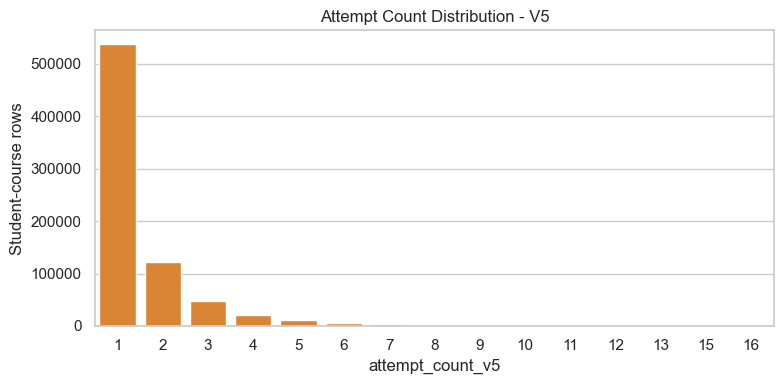

Validation passed: attempts calculated manually using part_id_base first.


In [41]:
assert len(df_attempt_calc_v5) > 0, "No clean-candidate rows available for attempt calculation."
assert df_attempt_calc_v5["attempt_number_v5"].ge(1).all()
assert df_attempt_calc_v5["attempt_count_v5"].ge(df_attempt_calc_v5["attempt_number_v5"]).all()
assert (
    df_attempt_calc_v5["is_last_attempt_calculated_v5"]
    == df_attempt_calc_v5["attempt_number_v5"].eq(df_attempt_calc_v5["attempt_count_v5"])
).all()

last_attempt_per_group_v5 = (
    df_attempt_calc_v5
    .groupby(student_course_attempt_group_cols_v5, dropna=False)["is_last_attempt_calculated_v5"]
    .sum()
    .reset_index(name="last_attempt_count")
)

assert last_attempt_per_group_v5["last_attempt_count"].eq(1).all(), \
    "Each student-course group must have exactly one calculated last attempt."

attempt_count_distribution_v5 = (
    df_attempt_calc_v5["attempt_count_v5"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)
attempt_count_distribution_v5.columns = ["attempt_count_v5", "count"]

plt.figure(figsize=(8, 4))
sns.barplot(
    data=attempt_count_distribution_v5,
    x="attempt_count_v5",
    y="count",
    color="#F58518",
)
plt.title("Attempt Count Distribution - V5")
plt.xlabel("attempt_count_v5")
plt.ylabel("Student-course rows")
plt.tight_layout()
plt.show()

print("Validation passed: attempts calculated manually using part_id_base first.")

## 20. Validate points, marks, and credits ranges

These checks create reports for outliers. They do not modify raw values.


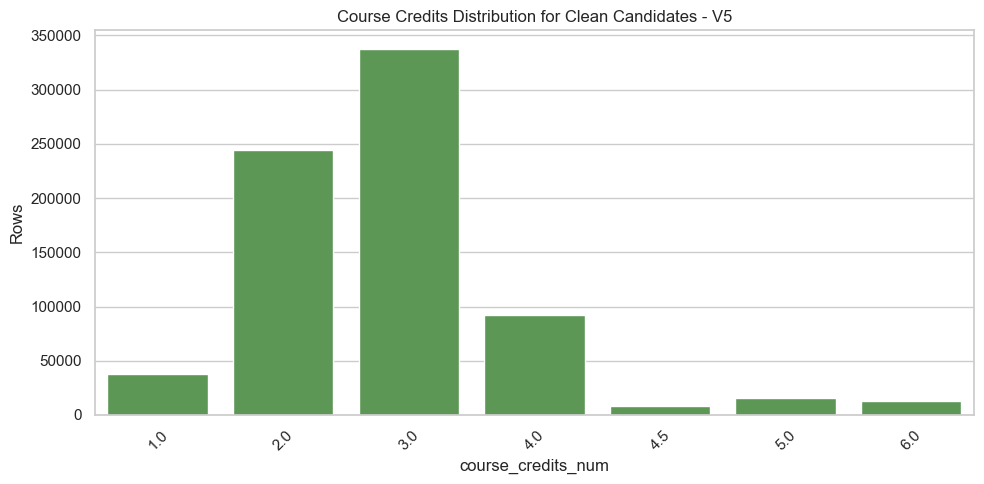

Points outliers: 0
Final mark outliers: 0


,course_credits_num,count
0,1.0,38122
1,2.0,244100
2,3.0,337857
3,4.0,91985
4,4.5,7877
5,5.0,15712
6,6.0,13241


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\points_outlier_rows_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\final_mark_outlier_rows_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\course_credits_distribution_clean_candidates_v5.csv


In [42]:
points_outlier_rows_v5 = df_attempts_normalized_v5[
    df_attempts_normalized_v5["points_float"].notna()
    & ~df_attempts_normalized_v5["points_float"].between(0, 4)
].copy()

final_mark_outlier_rows_v5 = df_attempts_normalized_v5[
    df_attempts_normalized_v5["final_mark_clean_v5"].notna()
    & ~df_attempts_normalized_v5["final_mark_clean_v5"].between(0, 100)
].copy()

course_credits_distribution_clean_candidates_v5 = (
    df_attempts_normalized_v5.loc[attempt_candidate_mask_v5, "course_credits_num"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)
course_credits_distribution_clean_candidates_v5.columns = ["course_credits_num", "count"]

points_outlier_rows_path_v5 = REPORTS_DIR / "points_outlier_rows_v5.csv"
final_mark_outlier_rows_path_v5 = REPORTS_DIR / "final_mark_outlier_rows_v5.csv"
course_credits_distribution_clean_candidates_path_v5 = (
    REPORTS_DIR / "course_credits_distribution_clean_candidates_v5.csv"
)

points_outlier_rows_v5.to_csv(points_outlier_rows_path_v5, index=False, encoding="utf-8-sig")
final_mark_outlier_rows_v5.to_csv(final_mark_outlier_rows_path_v5, index=False, encoding="utf-8-sig")
course_credits_distribution_clean_candidates_v5.to_csv(
    course_credits_distribution_clean_candidates_path_v5,
    index=False,
    encoding="utf-8-sig"
)

course_credits_plot_df_v5 = course_credits_distribution_clean_candidates_v5.sort_values(
    "course_credits_num"
)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=course_credits_plot_df_v5,
    x="course_credits_num",
    y="count",
    color="#54A24B",
)
plt.title("Course Credits Distribution for Clean Candidates - V5")
plt.xlabel("course_credits_num")
plt.ylabel("Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Points outliers:", len(points_outlier_rows_v5))
print("Final mark outliers:", len(final_mark_outlier_rows_v5))
display(course_credits_distribution_clean_candidates_v5)
print("Saved:", points_outlier_rows_path_v5)
print("Saved:", final_mark_outlier_rows_path_v5)
print("Saved:", course_credits_distribution_clean_candidates_path_v5)

In [43]:
assert points_outlier_rows_path_v5.exists()
assert final_mark_outlier_rows_path_v5.exists()
assert course_credits_distribution_clean_candidates_path_v5.exists()

print("Validation passed: numeric range reports saved.")

Validation passed: numeric range reports saved.


## 21. Build final clean attempts table

`df_clean_attempts_v5` keeps rows where:
- `is_archive_or_drop == False`
- `is_critical_issue == False`
- `finish_status_clean in KEEP_STATUSES_V5`

The final table carries only focused useful columns.


In [44]:
clean_attempts_mask_v5 = (
    ~df_attempts_normalized_v5["is_archive_or_drop"]
    & ~df_attempts_normalized_v5["is_critical_issue"]
    & df_attempts_normalized_v5["finish_status_clean"].isin(KEEP_STATUSES_V5)
)

requested_clean_columns_v5 = [
    # Identity/linking columns
    "student_course_id_key",
    "student_id_key",
    "course_id_key",
    "part_id_key",
    "grade_id_key",
    "degree_id_key",
    "faculty_id_key",
    
    # Base/order columns
    "student_course_id_base",
    "student_id_base",
    "course_id_base",
    "part_id_base",
    
    # Academic columns
    "finish_status_clean",
    "register_status_clean",
    "final_mark_clean_v5",
    "final_mark_clean_int_v5",
    "points_float",
    "course_credits_num",
    "course_credits_int",
    "course_name_clean",
    "degree_name_clean",
    "study_mode_clean",
    "active_clean",
    
    # Attempt columns
    "attempt_number_v5",
    "attempt_count_v5",
    "is_first_attempt_calculated_v5",
    "is_last_attempt_calculated_v5",
    "is_repeated_attempt_v5",
    
    # Important status flags
    "is_official_pass",
    "is_fail",
    "is_fail_like",
    "fail_family_v5",
    "is_withdrawn",
    "is_internal_performance_attempt",
    "is_in_progress",
    "is_registered_request_v5",
    "is_exam_only_request_v5",
    "is_removed_request_v5",
    "is_kept_register_status_v5",
    
    # Audit flags
    "final_mark_was_filled_zero_v5",
    "has_fractional_course_credits",
    "is_critical_issue",
    "is_archive_or_drop",
    "archive_drop_reason_v5",
    "_source_row_number_v5",
]

existing_clean_columns_v5 = [
    col for col in requested_clean_columns_v5
    if col in df_attempts_normalized_v5.columns
]

missing_nonessential_clean_columns_v5 = [
    col for col in requested_clean_columns_v5
    if col not in df_attempts_normalized_v5.columns
]

if missing_nonessential_clean_columns_v5:
    print("Missing non-essential requested columns:", missing_nonessential_clean_columns_v5)

# Sort final clean table by the same academic attempt order.
df_clean_attempts_v5 = (
    df_attempts_normalized_v5.loc[clean_attempts_mask_v5, existing_clean_columns_v5]
    .sort_values(
        ["student_id_key", "course_id_key", "part_id_base", "student_course_id_base", "_source_row_number_v5"],
        ascending=[True, True, True, True, True],
        na_position="last",
    )
    .copy()
)

# Backward-compatible alias if previous code expected this name.
df_attempts_clean_v5 = df_clean_attempts_v5.copy()

print("df_clean_attempts_v5 shape:", df_clean_attempts_v5.shape)
display(df_clean_attempts_v5.head())


df_clean_attempts_v5 shape: (748894, 44)


,student_course_id_key,student_id_key,course_id_key,part_id_key,grade_id_key,degree_id_key,faculty_id_key,student_course_id_base,student_id_base,course_id_base,part_id_base,finish_status_clean,register_status_clean,final_mark_clean_v5,final_mark_clean_int_v5,points_float,course_credits_num,course_credits_int,course_name_clean,degree_name_clean,study_mode_clean,active_clean,attempt_number_v5,attempt_count_v5,is_first_attempt_calculated_v5,is_last_attempt_calculated_v5,is_repeated_attempt_v5,is_official_pass,is_fail,is_fail_like,fail_family_v5,is_withdrawn,is_internal_performance_attempt,is_in_progress,is_registered_request_v5,is_exam_only_request_v5,is_removed_request_v5,is_kept_register_status_v5,final_mark_was_filled_zero_v5,has_fractional_course_credits,is_critical_issue,is_archive_or_drop,archive_drop_reason_v5,_source_row_number_v5
149587,939272.111,10000.111,1016.111,20152,677.111,3.111,5.111,939272,10000,1016,20152,P,R,82.0,82,3.00,2.0,2,المنطق والتفكير العلمي,هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,149588
132234,953865.111,10000.111,1017.111,20153,680.111,3.111,5.111,953865,10000,1017,20153,P,R,67.0,67,2.25,2.0,2,لغة اجنبية حية (ثانية),هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,132235
253026,1076397.111,10000.111,1019.111,20171,981.111,3.111,5.111,1076397,10000,1019,20171,P,R,66.0,66,2.25,2.0,2,مدخل الى القانون,هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,253027
93238,925010.111,10000.111,431.111,20152,677.111,3.111,5.111,925010,10000,431,20152,P,R,83.0,83,3.00,3.0,3,الرياضيات المتقطعة,هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,93239
67489,901340.111,10000.111,432.111,20151,681.111,3.111,5.111,901340,10000,432,20151,P,R,61.0,61,2.00,4.0,4,الجبر الخطي ونظرية المصفوفات,هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,67490


In [45]:
assert len(df_clean_attempts_v5) > 0, "df_clean_attempts_v5 must not be empty."
assert not df_clean_attempts_v5["is_archive_or_drop"].any(), "Clean table contains archive/drop rows."
assert not df_clean_attempts_v5["is_critical_issue"].any(), "Clean table contains critical issue rows."
assert "register_status_clean" in df_clean_attempts_v5.columns, "Missing register_status_clean in clean table."
assert df_clean_attempts_v5["finish_status_clean"].isin(KEEP_STATUSES_V5).all(), "Unexpected status in clean table."
assert df_clean_attempts_v5["attempt_number_v5"].ge(1).all(), "Invalid attempt_number_v5."
assert df_clean_attempts_v5["attempt_count_v5"].ge(df_clean_attempts_v5["attempt_number_v5"]).all(), \
    "attempt_count_v5 must be >= attempt_number_v5."
assert (
    df_clean_attempts_v5["is_last_attempt_calculated_v5"]
    == df_clean_attempts_v5["attempt_number_v5"].eq(df_clean_attempts_v5["attempt_count_v5"])
).all(), "is_last_attempt_calculated_v5 mismatch."
assert (
    df_clean_attempts_v5["is_official_pass"]
    == df_clean_attempts_v5["finish_status_clean"].isin(PASS_STATUSES_V5)
).all(), "is_official_pass mismatch."
assert (
    df_clean_attempts_v5["is_fail"]
    == df_clean_attempts_v5["finish_status_clean"].isin(FAIL_STATUSES_V5)
).all(), "is_fail mismatch."

fractional_clean_eligible_mask_v5 = (
    df_attempts_normalized_v5["has_fractional_course_credits"]
    & ~df_attempts_normalized_v5["is_archive_or_drop"]
    & ~df_attempts_normalized_v5["is_critical_issue"]
    & df_attempts_normalized_v5["finish_status_clean"].isin(KEEP_STATUSES_V5)
)
fractional_clean_eligible_source_rows_v5 = set(
    df_attempts_normalized_v5.loc[
        fractional_clean_eligible_mask_v5,
        "_source_row_number_v5",
    ].tolist()
)
clean_source_rows_v5 = set(df_clean_attempts_v5["_source_row_number_v5"].tolist())
assert fractional_clean_eligible_source_rows_v5.issubset(clean_source_rows_v5), \
    "Fractional credit clean-eligible rows must remain clean."

logical_duplicate_group_keys_v5 = register_status_group_summary_v5.loc[
    register_status_group_summary_v5["row_count"].gt(1),
    logical_duplicate_key_cols_v5,
]

if len(logical_duplicate_group_keys_v5) > 0:
    logical_duplicate_clean_rows_v5 = df_clean_attempts_v5.merge(
        logical_duplicate_group_keys_v5,
        on=logical_duplicate_key_cols_v5,
        how="inner",
    )
    assert logical_duplicate_clean_rows_v5["register_status_clean"].isin(
        REGISTER_STATUS_KEEP_STATUSES_V5
    ).all(), "Logical duplicate groups can keep only E/R register statuses clean."

print("Validation passed: df_clean_attempts_v5 is clean and focused.")

Validation passed: df_clean_attempts_v5 is clean and focused.


## 22. Save clean attempts reports

Generate required reports for the final clean table.


In [46]:
total_rows_before_cleaning_v5 = len(df_attempts_normalized_v5)
archive_drop_rows_count_v5 = int(df_attempts_normalized_v5["is_archive_or_drop"].sum())
critical_issue_rows_count_v5 = int(df_attempts_normalized_v5["is_critical_issue"].sum())
final_clean_rows_count_v5 = len(df_clean_attempts_v5)
excluded_union_count_v5 = int((~clean_attempts_mask_v5).sum())

clean_attempts_summary_v5 = pd.DataFrame([{
    "total_rows_before_cleaning": total_rows_before_cleaning_v5,
    "archive_drop_rows": archive_drop_rows_count_v5,
    "critical_issue_rows": critical_issue_rows_count_v5,
    "excluded_union_rows": excluded_union_count_v5,
    "final_clean_rows": final_clean_rows_count_v5,
    "clean_ratio": final_clean_rows_count_v5 / total_rows_before_cleaning_v5 if total_rows_before_cleaning_v5 else 0,
}])

clean_attempts_status_distribution_v5 = (
    df_clean_attempts_v5["finish_status_clean"]
    .value_counts(dropna=False)
    .reset_index()
)
clean_attempts_status_distribution_v5.columns = ["finish_status_clean", "count"]
clean_attempts_status_distribution_v5["row_count"] = len(df_clean_attempts_v5)
clean_attempts_status_distribution_v5["ratio"] = (
    clean_attempts_status_distribution_v5["count"] / len(df_clean_attempts_v5)
)

important_final_flags_v5 = [
    "is_official_pass",
    "is_fail",
    "is_fail_like",
    "fail_family_v5",
    "is_withdrawn",
    "is_internal_performance_attempt",
    "is_in_progress",
    "is_registered_request_v5",
    "is_exam_only_request_v5",
    "is_removed_request_v5",
    "is_kept_register_status_v5",
    "final_mark_was_filled_zero_v5",
    "has_fractional_course_credits",
    "is_critical_issue",
    "is_archive_or_drop",
    "is_first_attempt_calculated_v5",
    "is_last_attempt_calculated_v5",
    "is_repeated_attempt_v5",
]

existing_flag_columns_v5 = [
    flag for flag in important_final_flags_v5
    if flag in df_clean_attempts_v5.columns
]

clean_attempts_flag_summary_v5 = pd.DataFrame({
    "flag": existing_flag_columns_v5,
    "true_count": [int(df_clean_attempts_v5[flag].sum()) for flag in existing_flag_columns_v5],
    "false_count": [int((~df_clean_attempts_v5[flag]).sum()) for flag in existing_flag_columns_v5],
    "row_count": len(df_clean_attempts_v5),
})
clean_attempts_flag_summary_v5["true_ratio"] = (
    clean_attempts_flag_summary_v5["true_count"] / len(df_clean_attempts_v5)
)

clean_attempts_summary_path_v5 = REPORTS_DIR / "clean_attempts_summary_v5.csv"
clean_attempts_status_distribution_path_v5 = REPORTS_DIR / "clean_attempts_status_distribution_v5.csv"
clean_attempts_flag_summary_path_v5 = REPORTS_DIR / "clean_attempts_flag_summary_v5.csv"

clean_attempts_summary_v5.to_csv(clean_attempts_summary_path_v5, index=False, encoding="utf-8-sig")
clean_attempts_status_distribution_v5.to_csv(
    clean_attempts_status_distribution_path_v5,
    index=False,
    encoding="utf-8-sig"
)
clean_attempts_flag_summary_v5.to_csv(
    clean_attempts_flag_summary_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(clean_attempts_summary_v5)
display(clean_attempts_status_distribution_v5)
display(clean_attempts_flag_summary_v5)
print("Saved:", clean_attempts_summary_path_v5)
print("Saved:", clean_attempts_status_distribution_path_v5)
print("Saved:", clean_attempts_flag_summary_path_v5)


,total_rows_before_cleaning,archive_drop_rows,critical_issue_rows,excluded_union_rows,final_clean_rows,clean_ratio
0,960175,211280,154774,211281,748894,0.779956


,finish_status_clean,count,row_count,ratio
0,P,615422,748894,0.821775
1,F,95934,748894,0.128101
2,W,35859,748894,0.047883
3,FA,1105,748894,0.001476
4,FE,574,748894,0.000766


,flag,true_count,false_count,row_count,true_ratio
0,is_official_pass,615422,133472,748894,0.821775
1,is_fail,97613,651281,748894,0.130343
2,is_fail_like,1679,747215,748894,0.002242
3,fail_family_v5,97613,651281,748894,0.130343
4,is_withdrawn,35859,713035,748894,0.047883
5,is_internal_performance_attempt,713035,35859,748894,0.952117
6,is_in_progress,0,748894,748894,0.000000
7,is_registered_request_v5,734165,14729,748894,0.980332
8,is_exam_only_request_v5,14652,734242,748894,0.019565
9,is_removed_request_v5,55,748839,748894,0.000073


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\clean_attempts_summary_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\clean_attempts_status_distribution_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\clean_attempts_flag_summary_v5.csv


In [47]:
assert clean_attempts_summary_path_v5.exists()
assert clean_attempts_status_distribution_path_v5.exists()
assert clean_attempts_flag_summary_path_v5.exists()
assert clean_attempts_status_distribution_v5["finish_status_clean"].isin(KEEP_STATUSES_V5).all()

print("Validation passed: clean attempts reports saved.")

Validation passed: clean attempts reports saved.


## 23. Create df_student_course_current_status_v5

Current status is created from the calculated last attempt only.
No `is_last_try` column is used.


In [48]:
df_student_course_current_status_v5 = (
    df_clean_attempts_v5[
        df_clean_attempts_v5["is_last_attempt_calculated_v5"]
    ]
    .copy()
)

df_student_course_current_status_v5["current_status_v5"] = np.select(
    [
        df_student_course_current_status_v5["finish_status_clean"].isin(PASS_STATUSES_V5),
        df_student_course_current_status_v5["finish_status_clean"].isin(FAIL_STATUSES_V5),
        df_student_course_current_status_v5["finish_status_clean"].isin(WITHDRAWN_STATUSES_V5),
    ],
    [
        "passed",
        "failed",
        "withdrawn",
    ],
    default="review",
)

df_student_course_current_status_v5["current_is_passed_v5"] = (
    df_student_course_current_status_v5["finish_status_clean"].isin(PASS_STATUSES_V5)
)

df_student_course_current_status_v5["current_is_failed_v5"] = (
    df_student_course_current_status_v5["finish_status_clean"].isin(FAIL_STATUSES_V5)
)

df_student_course_current_status_v5["current_is_withdrawn_v5"] = (
    df_student_course_current_status_v5["finish_status_clean"].isin(WITHDRAWN_STATUSES_V5)
)

df_student_course_current_status_v5["current_is_transfer_v5"] = False
df_student_course_current_status_v5["current_is_in_progress_v5"] = False

current_duplicates_v5 = df_student_course_current_status_v5.duplicated(
    subset=["student_id_key", "course_id_key"]
).sum()

print("Current status rows:", len(df_student_course_current_status_v5))
print("Duplicate current student-course rows:", current_duplicates_v5)

display(df_student_course_current_status_v5.head())


Current status rows: 622603
Duplicate current student-course rows: 0


,student_course_id_key,student_id_key,course_id_key,part_id_key,grade_id_key,degree_id_key,faculty_id_key,student_course_id_base,student_id_base,course_id_base,part_id_base,finish_status_clean,register_status_clean,final_mark_clean_v5,final_mark_clean_int_v5,points_float,course_credits_num,course_credits_int,course_name_clean,degree_name_clean,study_mode_clean,active_clean,attempt_number_v5,attempt_count_v5,is_first_attempt_calculated_v5,is_last_attempt_calculated_v5,is_repeated_attempt_v5,is_official_pass,is_fail,is_fail_like,fail_family_v5,is_withdrawn,is_internal_performance_attempt,is_in_progress,is_registered_request_v5,is_exam_only_request_v5,is_removed_request_v5,is_kept_register_status_v5,final_mark_was_filled_zero_v5,has_fractional_course_credits,is_critical_issue,is_archive_or_drop,archive_drop_reason_v5,_source_row_number_v5,current_status_v5,current_is_passed_v5,current_is_failed_v5,current_is_withdrawn_v5,current_is_transfer_v5,current_is_in_progress_v5
149587,939272.111,10000.111,1016.111,20152,677.111,3.111,5.111,939272,10000,1016,20152,P,R,82.0,82,3.00,2.0,2,المنطق والتفكير العلمي,هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,149588,passed,True,False,False,False,False
132234,953865.111,10000.111,1017.111,20153,680.111,3.111,5.111,953865,10000,1017,20153,P,R,67.0,67,2.25,2.0,2,لغة اجنبية حية (ثانية),هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,132235,passed,True,False,False,False,False
253026,1076397.111,10000.111,1019.111,20171,981.111,3.111,5.111,1076397,10000,1019,20171,P,R,66.0,66,2.25,2.0,2,مدخل الى القانون,هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,253027,passed,True,False,False,False,False
93238,925010.111,10000.111,431.111,20152,677.111,3.111,5.111,925010,10000,431,20152,P,R,83.0,83,3.00,3.0,3,الرياضيات المتقطعة,هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,93239,passed,True,False,False,False,False
67489,901340.111,10000.111,432.111,20151,681.111,3.111,5.111,901340,10000,432,20151,P,R,61.0,61,2.00,4.0,4,الجبر الخطي ونظرية المصفوفات,هندسة البرمجيات ونظم المعلومات,C,A,1,1,True,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,,67490,passed,True,False,False,False,False


In [49]:
assert len(df_student_course_current_status_v5) > 0, "df_student_course_current_status_v5 must not be empty."
assert current_duplicates_v5 == 0, "Current status has duplicate student-course rows."
assert df_student_course_current_status_v5["student_id_key"].notna().all()
assert df_student_course_current_status_v5["course_id_key"].notna().all()
assert df_student_course_current_status_v5["is_last_attempt_calculated_v5"].all()

print("Validation passed: one current status row per student-course combination.")


Validation passed: one current status row per student-course combination.


## 24. Save current status distribution report

This report checks the final current academic status distribution.


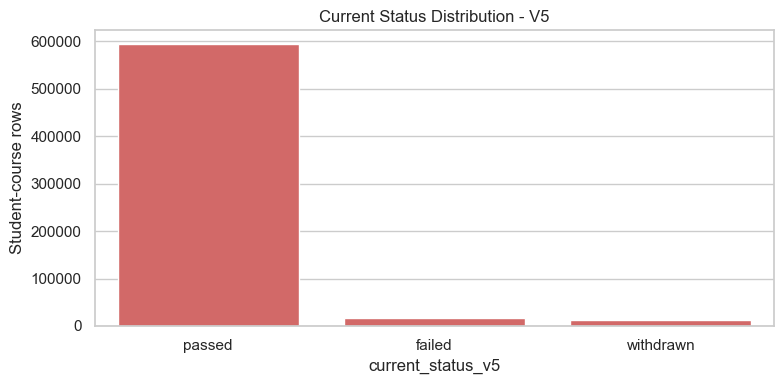

,current_status_v5,count,row_count,ratio
0,passed,593224,622603,0.952813
1,failed,15946,622603,0.025612
2,withdrawn,13433,622603,0.021576


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\current_status_distribution_v5.csv


In [50]:
current_status_distribution_v5 = (
    df_student_course_current_status_v5["current_status_v5"]
    .value_counts(dropna=False)
    .reset_index()
)

current_status_distribution_v5.columns = ["current_status_v5", "count"]
current_status_distribution_v5["row_count"] = len(df_student_course_current_status_v5)
current_status_distribution_v5["ratio"] = (
    current_status_distribution_v5["count"] / len(df_student_course_current_status_v5)
)

current_status_distribution_path_v5 = REPORTS_DIR / "current_status_distribution_v5.csv"
current_status_distribution_v5.to_csv(
    current_status_distribution_path_v5,
    index=False,
    encoding="utf-8-sig",
)

current_status_plot_df_v5 = current_status_distribution_v5.sort_values("count", ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(
    data=current_status_plot_df_v5,
    x="current_status_v5",
    y="count",
    color="#E45756",
)
plt.title("Current Status Distribution - V5")
plt.xlabel("current_status_v5")
plt.ylabel("Student-course rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(current_status_distribution_v5)
print("Saved:", current_status_distribution_path_v5)


In [51]:
assert current_status_distribution_path_v5.exists()
assert current_status_distribution_v5["count"].sum() == len(df_student_course_current_status_v5)

print("Validation passed: current status distribution is consistent.")


Validation passed: current status distribution is consistent.


## 25. Save final output files

Save:
- `df_attempts_normalized_v5`
- `archive_drop_rows_v5`
- `df_clean_attempts_v5`
- `df_student_course_current_status_v5`

Parquet is the main storage format. CSV is for inspection.


In [52]:
df_attempts_normalized_parquet_path_v5 = PREPROCESSED_DIR / "df_attempts_normalized_v5.parquet"
df_attempts_normalized_csv_path_v5 = PREPROCESSED_DIR / "df_attempts_normalized_v5.csv"

df_clean_attempts_parquet_path_v5 = PREPROCESSED_DIR / "df_clean_attempts_v5.parquet"
df_clean_attempts_csv_path_v5 = PREPROCESSED_DIR / "df_clean_attempts_v5.csv"

# Backward-compatible filenames for older notebook references.
df_attempts_clean_parquet_path_v5 = PREPROCESSED_DIR / "df_attempts_clean_v5.parquet"
df_attempts_clean_csv_path_v5 = PREPROCESSED_DIR / "df_attempts_clean_v5.csv"

df_current_status_parquet_path_v5 = FEATURES_DIR / "df_student_course_current_status_v5.parquet"
df_current_status_csv_path_v5 = FEATURES_DIR / "df_student_course_current_status_v5.csv"

df_attempts_normalized_v5.to_parquet(df_attempts_normalized_parquet_path_v5, index=False)
df_attempts_normalized_v5.to_csv(df_attempts_normalized_csv_path_v5, index=False, encoding="utf-8-sig")

df_clean_attempts_v5.to_parquet(df_clean_attempts_parquet_path_v5, index=False)
df_clean_attempts_v5.to_csv(df_clean_attempts_csv_path_v5, index=False, encoding="utf-8-sig")

# Same content as df_clean_attempts_v5, saved for compatibility with the previous naming convention.
df_attempts_clean_v5.to_parquet(df_attempts_clean_parquet_path_v5, index=False)
df_attempts_clean_v5.to_csv(df_attempts_clean_csv_path_v5, index=False, encoding="utf-8-sig")

df_student_course_current_status_v5.to_parquet(df_current_status_parquet_path_v5, index=False)
df_student_course_current_status_v5.to_csv(df_current_status_csv_path_v5, index=False, encoding="utf-8-sig")

print("Saved:", df_attempts_normalized_parquet_path_v5)
print("Saved:", df_attempts_normalized_csv_path_v5)
print("Saved:", archive_drop_rows_parquet_path_v5)
print("Saved:", archive_drop_rows_csv_path_v5)
print("Saved:", df_clean_attempts_parquet_path_v5)
print("Saved:", df_clean_attempts_csv_path_v5)
print("Saved compatibility:", df_attempts_clean_parquet_path_v5)
print("Saved compatibility:", df_attempts_clean_csv_path_v5)
print("Saved:", df_current_status_parquet_path_v5)
print("Saved:", df_current_status_csv_path_v5)


Saved: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_attempts_normalized_v5.parquet
Saved: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_attempts_normalized_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\archive_drop_rows_v5.parquet
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\archive_drop_rows_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_clean_attempts_v5.parquet
Saved: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_clean_attempts_v5.csv
Saved compatibility: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_attempts_clean_v5.parquet
Saved compatibility: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_attempts_clean_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\data\features\V_CRG_STUDENT_COURSE\df_student_course_curre

In [53]:
required_output_paths_v5 = [
    df_attempts_normalized_parquet_path_v5,
    df_attempts_normalized_csv_path_v5,
    archive_drop_rows_parquet_path_v5,
    archive_drop_rows_csv_path_v5,
    df_clean_attempts_parquet_path_v5,
    df_clean_attempts_csv_path_v5,
    df_attempts_clean_parquet_path_v5,
    df_attempts_clean_csv_path_v5,
    df_current_status_parquet_path_v5,
    df_current_status_csv_path_v5,
]

for path in required_output_paths_v5:
    assert path.exists(), f"Missing output file: {path}"

print("Validation passed: all final output files saved.")


Validation passed: all final output files saved.


## 26. Final validation summary

This report summarizes the important final validation checks.


In [54]:
last_attempt_count_check_v5 = (
    df_clean_attempts_v5
    .groupby(["student_id_key", "course_id_key"], dropna=False)["is_last_attempt_calculated_v5"]
    .sum()
    .reset_index(name="last_attempt_count")
)

validation_summary_v5 = pd.DataFrame([
    {
        "check_name": "raw_file_exists",
        "status": RAW_PATH.exists(),
        "value": str(RAW_PATH),
    },
    {
        "check_name": "raw_rows",
        "status": len(df_raw_v5) > 0,
        "value": len(df_raw_v5),
    },
    {
        "check_name": "required_columns_exist",
        "status": len(missing_required_columns_v5) == 0,
        "value": str(missing_required_columns_v5),
    },
    {
        "check_name": "exact_duplicates_reported",
        "status": duplicate_rows_path_v5.exists(),
        "value": len(df_duplicate_rows_v5),
    },
    {
        "check_name": "null_handling_report_saved",
        "status": null_handling_report_path_v5.exists(),
        "value": str(null_handling_report_path_v5),
    },
    {
        "check_name": "course_credits_null_report_saved",
        "status": course_credits_null_report_path_v5.exists(),
        "value": str(course_credits_null_report_path_v5),
    },
    {
        "check_name": "register_status_distribution_saved",
        "status": register_status_distribution_path_v5.exists(),
        "value": str(register_status_distribution_path_v5),
    },
    {
        "check_name": "register_status_duplicate_resolution_report_saved",
        "status": register_status_duplicate_resolution_report_path_v5.exists(),
        "value": str(register_status_duplicate_resolution_report_path_v5),
    },
    {
        "check_name": "logical_duplicate_registered_rows_saved",
        "status": logical_duplicate_registered_rows_path_v5.exists(),
        "value": str(logical_duplicate_registered_rows_path_v5),
    },
    {
        "check_name": "duplicate_student_course_id_rows_saved",
        "status": duplicate_student_course_id_rows_path_v5.exists(),
        "value": str(duplicate_student_course_id_rows_path_v5),
    },
    {
        "check_name": "fractional_course_credits_audit_only",
        "status": (
            ~archive_drop_rows_v5["archive_drop_reason_v5"].str.contains("fractional_course_credits", regex=False, na=False)
        ).all()
        and (
            ~critical_issue_rows_v5["critical_issue_reason_v5"].str.contains("fractional_course_credits", regex=False, na=False)
        ).all(),
        "value": int(df_attempts_normalized_v5["has_fractional_course_credits"].sum()),
    },
    {
        "check_name": "fractional_clean_eligible_rows_kept",
        "status": fractional_clean_eligible_source_rows_v5.issubset(clean_source_rows_v5),
        "value": len(fractional_clean_eligible_source_rows_v5),
    },
    {
        "check_name": "clean_attempts_not_empty",
        "status": len(df_clean_attempts_v5) > 0,
        "value": len(df_clean_attempts_v5),
    },
    {
        "check_name": "clean_has_no_archive_drop_rows",
        "status": not df_clean_attempts_v5["is_archive_or_drop"].any(),
        "value": int(df_clean_attempts_v5["is_archive_or_drop"].sum()),
    },
    {
        "check_name": "clean_has_no_critical_rows",
        "status": not df_clean_attempts_v5["is_critical_issue"].any(),
        "value": int(df_clean_attempts_v5["is_critical_issue"].sum()),
    },
    {
        "check_name": "clean_statuses_are_expected",
        "status": df_clean_attempts_v5["finish_status_clean"].isin(KEEP_STATUSES_V5).all(),
        "value": sorted(df_clean_attempts_v5["finish_status_clean"].dropna().unique().tolist()),
    },
    {
        "check_name": "logical_duplicates_keep_only_e_or_r_clean",
        "status": (
            True
            if len(logical_duplicate_group_keys_v5) == 0
            else logical_duplicate_clean_rows_v5["register_status_clean"].isin(REGISTER_STATUS_KEEP_STATUSES_V5).all()
        ),
        "value": len(logical_duplicate_group_keys_v5),
    },
    {
        "check_name": "id_float_suffix_normalization",
        "status": normalize_id_to_string("20111.000") == "20111" and normalize_id_to_string("1491.111") == "1491.111",
        "value": "20111.000 -> 20111; 1491.111 suffix preserved",
    },
    {
        "check_name": "attempt_number_valid",
        "status": df_clean_attempts_v5["attempt_number_v5"].ge(1).all(),
        "value": int(df_clean_attempts_v5["attempt_number_v5"].min()),
    },
    {
        "check_name": "attempt_count_ge_attempt_number",
        "status": df_clean_attempts_v5["attempt_count_v5"].ge(df_clean_attempts_v5["attempt_number_v5"]).all(),
        "value": "checked",
    },
    {
        "check_name": "one_last_attempt_per_student_course",
        "status": last_attempt_count_check_v5["last_attempt_count"].eq(1).all(),
        "value": int((~last_attempt_count_check_v5["last_attempt_count"].eq(1)).sum()),
    },
    {
        "check_name": "is_official_pass_matches_finish_status",
        "status": (
            df_clean_attempts_v5["is_official_pass"]
            == df_clean_attempts_v5["finish_status_clean"].isin(PASS_STATUSES_V5)
        ).all(),
        "value": "checked",
    },
    {
        "check_name": "is_fail_matches_finish_status",
        "status": (
            df_clean_attempts_v5["is_fail"]
            == df_clean_attempts_v5["finish_status_clean"].isin(FAIL_STATUSES_V5)
        ).all(),
        "value": "checked",
    },
    {
        "check_name": "df_attempts_normalized_v5_saved",
        "status": df_attempts_normalized_parquet_path_v5.exists(),
        "value": str(df_attempts_normalized_parquet_path_v5),
    },
    {
        "check_name": "archive_drop_rows_v5_saved",
        "status": archive_drop_rows_parquet_path_v5.exists(),
        "value": str(archive_drop_rows_parquet_path_v5),
    },
    {
        "check_name": "df_clean_attempts_v5_saved",
        "status": df_clean_attempts_parquet_path_v5.exists(),
        "value": str(df_clean_attempts_parquet_path_v5),
    },
    {
        "check_name": "df_student_course_current_status_v5_saved",
        "status": df_current_status_parquet_path_v5.exists(),
        "value": str(df_current_status_parquet_path_v5),
    },
])

validation_summary_path_v5 = REPORTS_DIR / "validation_summary_v5.csv"
validation_summary_v5.to_csv(validation_summary_path_v5, index=False, encoding="utf-8-sig")

display(validation_summary_v5)
print("Saved:", validation_summary_path_v5)


,check_name,status,value
0,raw_file_exists,True,D:\AI\Real projects\Academic_Advisor\data\raw\...
1,raw_rows,True,965467
2,required_columns_exist,True,[]
3,exact_duplicates_reported,True,5292
4,null_handling_report_saved,True,D:\AI\Real projects\Academic_Advisor\reports\V...
5,course_credits_null_report_saved,True,D:\AI\Real projects\Academic_Advisor\reports\V...
6,register_status_distribution_saved,True,D:\AI\Real projects\Academic_Advisor\reports\V...
7,register_status_duplicate_resolution_report_saved,True,D:\AI\Real projects\Academic_Advisor\reports\V...
8,logical_duplicate_registered_rows_saved,True,D:\AI\Real projects\Academic_Advisor\reports\V...
9,duplicate_student_course_id_rows_saved,True,D:\AI\Real projects\Academic_Advisor\reports\V...


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\validation_summary_v5.csv


In [55]:
assert validation_summary_path_v5.exists()
assert validation_summary_v5["status"].all(), "Some validation checks failed."

print("V5 preprocessing completed successfully.")
print("Created: df_attempts_normalized_v5")
print("Created: archive_drop_rows_v5")
print("Created: df_clean_attempts_v5")
print("Created compatibility alias: df_attempts_clean_v5")
print("Created: df_student_course_current_status_v5")
print("No models built.")
print("No course difficulty built.")
print("No recommendation logic built.")


V5 preprocessing completed successfully.
Created: df_attempts_normalized_v5
Created: archive_drop_rows_v5
Created: df_clean_attempts_v5
Created compatibility alias: df_attempts_clean_v5
Created: df_student_course_current_status_v5
No models built.
No course difficulty built.
No recommendation logic built.
